Figura guardada como: F_quadratic_surface_axes.png


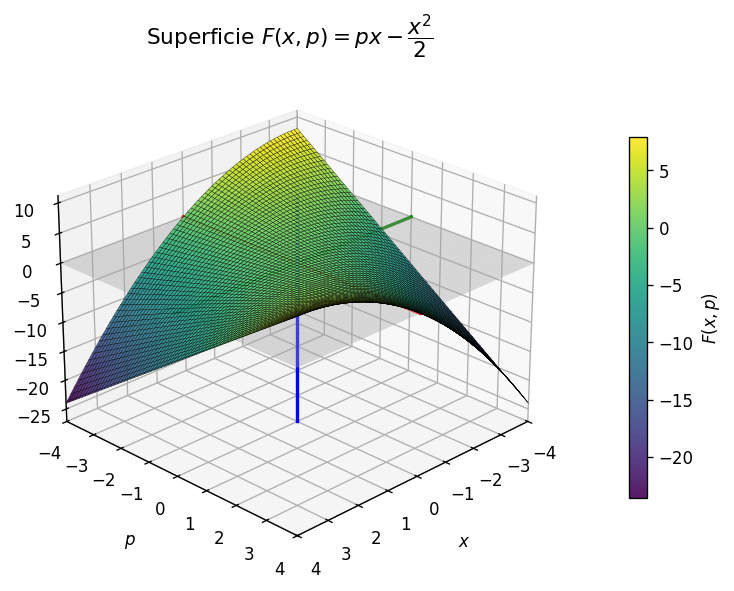

Figura guardada como: F_cubic_surface_axes.png


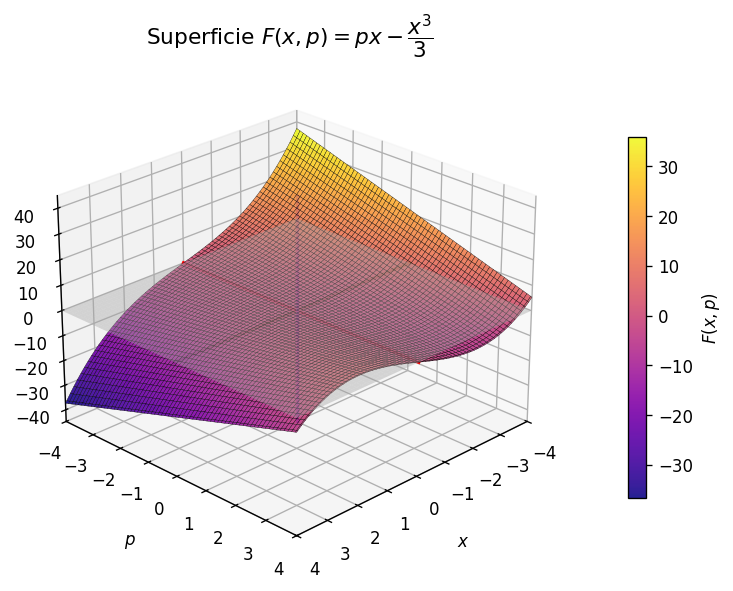

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # necesario en algunos entornos

# ==============================
# Definición de funciones
# ==============================

def F_quad(x, p):
    return p * x - x**2 / 2.0

def F_cubic(x, p):
    return p * x - x**3 / 3.0

# Rango común para x y p
x_min, x_max = -4, 4
p_min, p_max = -4, 4
n_grid = 200

x = np.linspace(x_min, x_max, n_grid)
p = np.linspace(p_min, p_max, n_grid)
X, P = np.meshgrid(x, p)

# ==============================
# Función auxiliar para graficar con ejes "tipo GeoGebra"
# ==============================

def plot_surface_with_axes(Zfunc, title, filename, cmap="viridis"):
    Z = Zfunc(X, P)

    fig = plt.figure(figsize=(7, 5), dpi=120)
    ax = fig.add_subplot(111, projection="3d")

    # --- plano F = 0 (gris) ---
    Z0 = np.zeros_like(Z)
    ax.plot_surface(
        X, P, Z0,
        color="lightgray",
        alpha=0.4,
        linewidth=0
    )

    # --- superficie F(x,p) ---
    surf = ax.plot_surface(
        X, P, Z,
        cmap=cmap,
        rstride=3,
        cstride=3,
        linewidth=0.2,
        edgecolor="k",
        alpha=0.9
    )

    # --- límites para que los ejes se vean centrados ---
    z_min = Z.min()
    z_max = Z.max()
    margen_z = 0.1 * (z_max - z_min)
    z_min -= margen_z
    z_max += margen_z

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(p_min, p_max)
    ax.set_zlim(z_min, z_max)

    # --- ejes coloreados que pasan por el origen ---
    # Eje x (verde)
    ax.plot([x_min, x_max], [0, 0], [0, 0], color="green", linewidth=2)
    # Eje p (rojo)
    ax.plot([0, 0], [p_min, p_max], [0, 0], color="red", linewidth=2)
    # Eje F (azul)
    ax.plot([0, 0], [0, 0], [z_min, z_max], color="blue", linewidth=2)

    # --- etiquetas ---
    ax.set_xlabel(r"$x$", labelpad=10)
    ax.set_ylabel(r"$p$", labelpad=10)
    ax.set_zlabel(r"$F(x,p)$", labelpad=10)

    ax.set_title(title, fontsize=13)

    # Vista más “clásica”
    ax.view_init(elev=25, azim=45)

    # Barra de color
    fig.colorbar(surf, ax=ax, shrink=0.7, pad=0.1, label=r"$F(x,p)$")

    plt.tight_layout()
    fig.savefig(filename, dpi=600, bbox_inches="tight")
    print(f"Figura guardada como: {filename}")
    plt.show()

# ==============================
# (a) Superficie cuadrática
# ==============================

plot_surface_with_axes(
    Zfunc=F_quad,
    title=r"Superficie $F(x,p)=px-\dfrac{x^{2}}{2}$",
    filename="F_quadratic_surface_axes.png",
    cmap="viridis"
)

# ==============================
# (a) Superficie cúbica
# ==============================

plot_surface_with_axes(
    Zfunc=F_cubic,
    title=r"Superficie $F(x,p)=px-\dfrac{x^{3}}{3}$",
    filename="F_cubic_surface_axes.png",
    cmap="plasma"
)


Figura guardada como: F_quadratic_geo_axes.png


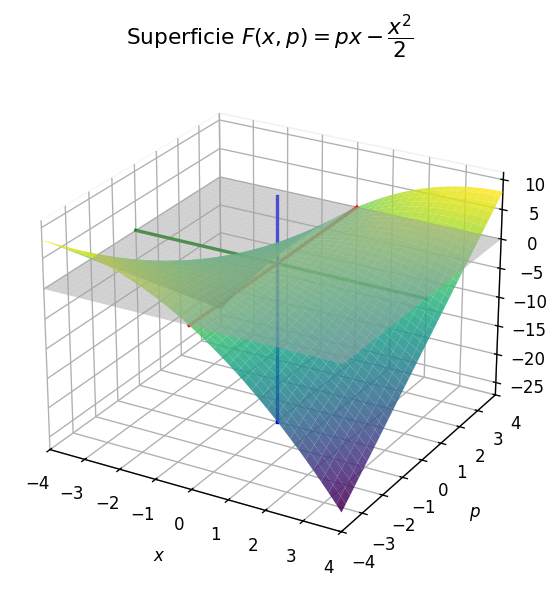

Figura guardada como: F_cubic_geo_axes.png


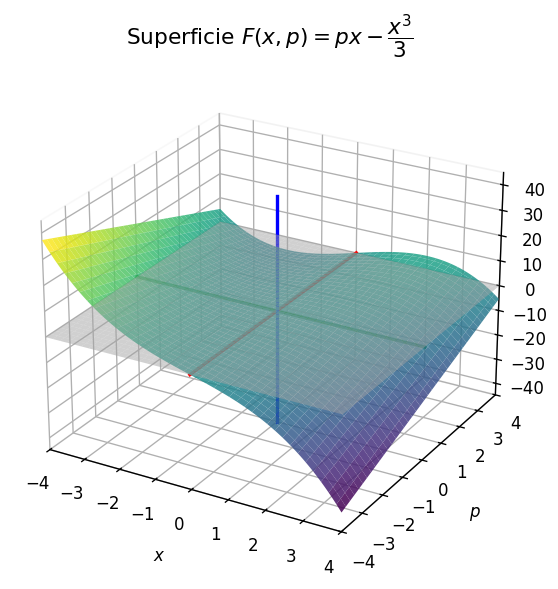

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # en algunos entornos sigue siendo necesario

# ==========================
# Funciones
# ==========================

def F_quad(x, p):
    return p * x - x**2 / 2.0

def F_cubic(x, p):
    return p * x - x**3 / 3.0

# Rango
x_min, x_max = -4, 4
p_min, p_max = -4, 4
n_grid = 120

x = np.linspace(x_min, x_max, n_grid)
p = np.linspace(p_min, p_max, n_grid)
X, P = np.meshgrid(x, p)

# ==========================
# Función auxiliar: estilo "ejes clásicos"
# ==========================

def grafica_superficie(Zfunc, titulo, archivo_salida):
    Z = Zfunc(X, P)

    fig = plt.figure(figsize=(7, 5), dpi=120)
    ax = fig.add_subplot(111, projection="3d")

    # -------- plano F = 0 (gris) ----------
    Z0 = np.zeros_like(Z)
    ax.plot_surface(
        X, P, Z0,
        color="lightgray",
        alpha=0.5,
        linewidth=0,
        antialiased=True
    )

    # -------- superficie F(x,p) ----------
    ax.plot_surface(
        X, P, Z,
        cmap="viridis",
        edgecolor="none",
        alpha=0.85
    )

    # -------- ejes tipo GeoGebra ----------
    # límites en F
    z_min = Z.min()
    z_max = Z.max()
    margen_z = 0.1 * (z_max - z_min)
    z_min -= margen_z
    z_max += margen_z

    ax.set_xlim(x_min, x_max)
    ax.set_ylim(p_min, p_max)
    ax.set_zlim(z_min, z_max)

    # eje x (verde)
    ax.plot([x_min, x_max], [0, 0], [0, 0], color="green", linewidth=2)
    # eje p (rojo)
    ax.plot([0, 0], [p_min, p_max], [0, 0], color="red", linewidth=2)
    # eje F (azul)
    ax.plot([0, 0], [0, 0], [z_min, z_max], color="blue", linewidth=2)

    # -------- quitar aspecto "cubo" ----------
    ax.xaxis.pane.fill = False
    ax.yaxis.pane.fill = False
    ax.zaxis.pane.fill = False
    ax.grid(True, linestyle=":", linewidth=0.5)

    # etiquetas
    ax.set_xlabel(r"$x$", labelpad=8)
    ax.set_ylabel(r"$p$", labelpad=8)
    ax.set_zlabel(r"$F(x,p)$", labelpad=8)
    ax.set_title(titulo, fontsize=13)

    # vista más "de libro": plano horizontal, eje F vertical
    ax.view_init(elev=25, azim=-60)

    plt.tight_layout()
    fig.savefig(archivo_salida, dpi=600, bbox_inches="tight")
    print(f"Figura guardada como: {archivo_salida}")
    plt.show()

# ==========================
# Cuadrática: F(x,p) = p x - x^2/2
# ==========================

grafica_superficie(
    Zfunc=F_quad,
    titulo=r"Superficie $F(x,p)=px-\dfrac{x^{2}}{2}$",
    archivo_salida="F_quadratic_geo_axes.png"
)

# ==========================
# Cúbica: F(x,p) = p x - x^3/3
# ==========================

grafica_superficie(
    Zfunc=F_cubic,
    titulo=r"Superficie $F(x,p)=px-\dfrac{x^{3}}{3}$",
    archivo_salida="F_cubic_geo_axes.png"
)


AttributeError: 'Axes3D' object has no attribute 'w_xaxis'

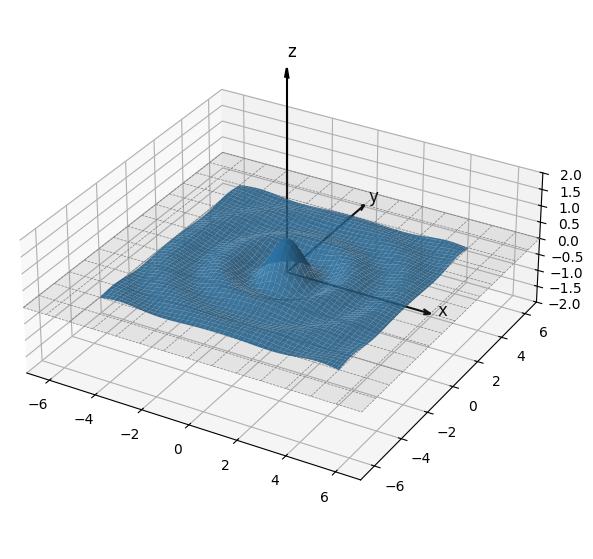

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =======================
#  Superficie de ejemplo
# =======================
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
Z = np.sinc(R)    # sinc(r) = sin(pi r)/(pi r)

# =======================
#  Figura 3D
# =======================
fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# ----- Superficie -----
ax.plot_surface(X, Y, Z, rstride=2, cstride=2, alpha=0.9)

# =======================
#  Plano XY "infinite grid"
# =======================
L = 7   # tamaño del plano
grid = np.linspace(-L, L, 15)

# líneas en dirección x (paralelas al eje x)
for yy in grid:
    ax.plot([-L, L], [yy, yy], [0, 0], linestyle='--', linewidth=0.5, color='gray')

# líneas en dirección y (paralelas al eje y)
for xx in grid:
    ax.plot([xx, xx], [-L, L], [0, 0], linestyle='--', linewidth=0.5, color='gray')

# plano XY semitransparente
PX, PY = np.meshgrid(grid, grid)
PZ = np.zeros_like(PX)
ax.plot_surface(PX, PY, PZ, alpha=0.15, shade=False, color='gray')

# =======================
#  Ejes con flechas
# =======================
axis_len = 6

ax.quiver(0, 0, 0, axis_len, 0, 0,
          arrow_length_ratio=0.05, color='k')
ax.quiver(0, 0, 0, 0, axis_len, 0,
          arrow_length_ratio=0.05, color='k')
ax.quiver(0, 0, 0, 0, 0, axis_len,
          arrow_length_ratio=0.05, color='k')

ax.text(axis_len*1.05, 0, 0, 'x', fontsize=12)
ax.text(0, axis_len*1.05, 0, 'y', fontsize=12)
ax.text(0, 0, axis_len*1.05, 'z', fontsize=12)

# =======================
#  Ajustes de vista
# =======================
ax.set_xlim(-L, L)
ax.set_ylim(-L, L)
ax.set_zlim(-2, 2)
ax.set_box_aspect((1, 1, 0.4))   # más “aplanado”, tipo GeoGebra

# Quitamos la "caja" para que se vea más limpio
ax.w_xaxis.line.set_lw(0.)
ax.w_yaxis.line.set_lw(0.)
ax.w_zaxis.line.set_lw(0.)
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

plt.show()


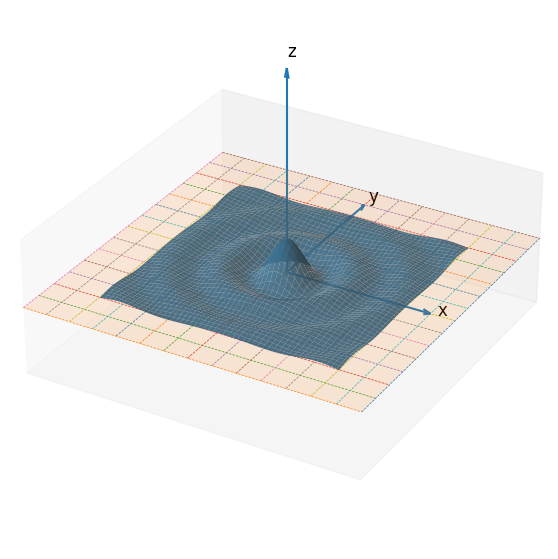

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =======================
#  Superficie de ejemplo
# =======================
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
Z = np.sinc(R)    # sinc(r) = sin(pi r)/(pi r)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# ----- Superficie -----
ax.plot_surface(X, Y, Z, rstride=2, cstride=2, alpha=0.9)

# =======================
#  Plano XY "infinite grid"
# =======================
L = 7   # tamaño del plano
grid = np.linspace(-L, L, 15)

# líneas en dirección x
for yy in grid:
    ax.plot([-L, L], [yy, yy], [0, 0],
            linestyle='--', linewidth=0.5)

# líneas en dirección y
for xx in grid:
    ax.plot([xx, xx], [-L, L], [0, 0],
            linestyle='--', linewidth=0.5)

# plano XY semitransparente
PX, PY = np.meshgrid(grid, grid)
PZ = np.zeros_like(PX)
ax.plot_surface(PX, PY, PZ, alpha=0.15, shade=False)

# =======================
#  Ejes con flechas
# =======================
axis_len = 6

ax.quiver(0, 0, 0, axis_len, 0, 0,
          arrow_length_ratio=0.05)
ax.quiver(0, 0, 0, 0, axis_len, 0,
          arrow_length_ratio=0.05)
ax.quiver(0, 0, 0, 0, 0, axis_len,
          arrow_length_ratio=0.05)

ax.text(axis_len*1.05, 0, 0, 'x', fontsize=12)
ax.text(0, axis_len*1.05, 0, 'y', fontsize=12)
ax.text(0, 0, axis_len*1.05, 'z', fontsize=12)

# =======================
#  Ajustes de vista
# =======================
ax.set_xlim(-L, L)
ax.set_ylim(-L, L)
ax.set_zlim(-2, 2)
ax.set_box_aspect((1, 1, 0.4))   # más “aplanado”, tipo GeoGebra

# Quitar bordes de la caja
ax.xaxis.line.set_linewidth(0)
ax.yaxis.line.set_linewidth(0)
ax.zaxis.line.set_linewidth(0)

# Opcional: quitar ticks para que se vea más limpio
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

plt.show()


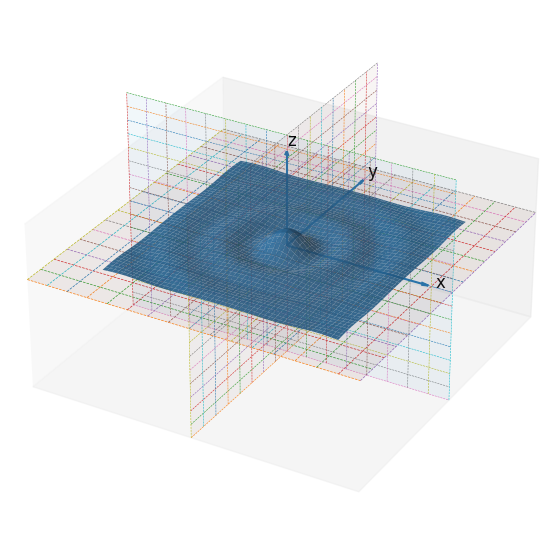

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =======================
#  Superficie de ejemplo
# =======================
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
Z = np.sinc(R)    # sinc(r) = sin(pi r)/(pi r)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# ----- Superficie -----
ax.plot_surface(X, Y, Z, rstride=2, cstride=2, alpha=0.9)

# =======================
#  Planos coordenados "infinite grid"
# =======================
L = 7   # tamaño de los planos
grid = np.linspace(-L, L, 17)

# ----- Plano XY (z = 0) -----
for yy in grid:
    ax.plot([-L, L], [yy, yy], [0, 0],
            linestyle='--', linewidth=0.5)
for xx in grid:
    ax.plot([xx, xx], [-L, L], [0, 0],
            linestyle='--', linewidth=0.5)

PX, PY = np.meshgrid(grid, grid)
PZ = np.zeros_like(PX)
ax.plot_surface(PX, PY, PZ, alpha=0.10, shade=False)

# ----- Plano XZ (y = 0) -----
for zz in grid:
    ax.plot([-L, L], [0, 0], [zz, zz],
            linestyle='--', linewidth=0.4)
for xx in grid:
    ax.plot([xx, xx], [0, 0], [-L, L],
            linestyle='--', linewidth=0.4)

PX, PZ = np.meshgrid(grid, grid)
PY = np.zeros_like(PX)
ax.plot_surface(PX, PY, PZ, alpha=0.06, shade=False)

# ----- Plano YZ (x = 0) -----
for zz in grid:
    ax.plot([0, 0], [-L, L], [zz, zz],
            linestyle='--', linewidth=0.4)
for yy in grid:
    ax.plot([0, 0], [yy, yy], [-L, L],
            linestyle='--', linewidth=0.4)

PY, PZ = np.meshgrid(grid, grid)
PX = np.zeros_like(PY)
ax.plot_surface(PX, PY, PZ, alpha=0.06, shade=False)

# =======================
#  Ejes con flechas
# =======================
axis_len = 6

ax.quiver(0, 0, 0, axis_len, 0, 0,
          arrow_length_ratio=0.05)
ax.quiver(0, 0, 0, 0, axis_len, 0,
          arrow_length_ratio=0.05)
ax.quiver(0, 0, 0, 0, 0, axis_len,
          arrow_length_ratio=0.05)

ax.text(axis_len*1.05, 0, 0, 'x', fontsize=12)
ax.text(0, axis_len*1.05, 0, 'y', fontsize=12)
ax.text(0, 0, axis_len*1.05, 'z', fontsize=12)

# =======================
#  Ajustes de vista
# =======================
ax.set_xlim(-L, L)
ax.set_ylim(-L, L)
ax.set_zlim(-L, L/2)       # un poco aplastado hacia abajo
ax.set_box_aspect((1, 1, 0.5))   # estilo GeoGebra

# Quitar bordes de la "caja" y ticks
ax.xaxis.line.set_linewidth(0)
ax.yaxis.line.set_linewidth(0)
ax.zaxis.line.set_linewidth(0)
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

plt.show()


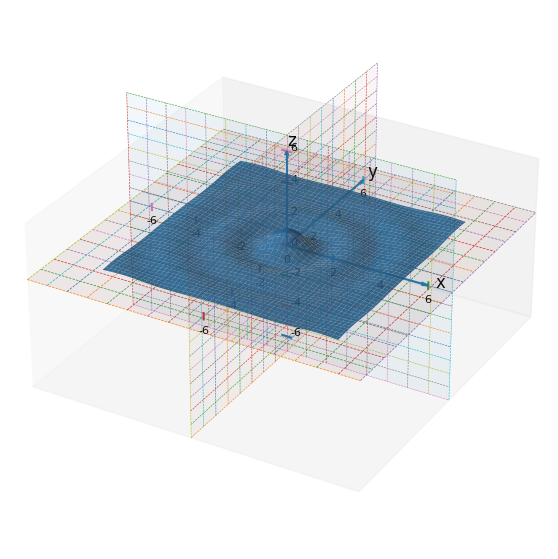

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =======================
#  Superficie de ejemplo
# =======================
x = np.linspace(-5, 5, 100)
y = np.linspace(-5, 5, 100)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
Z = np.sinc(R)    # sinc(r) = sin(pi r)/(pi r)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# ----- Superficie -----
ax.plot_surface(X, Y, Z, rstride=2, cstride=2, alpha=0.9)

# =======================
#  Planos coordenados "infinite grid"
# =======================
L = 7   # tamaño de los planos
grid = np.linspace(-L, L, 17)

# ----- Plano XY (z = 0) -----
for yy in grid:
    ax.plot([-L, L], [yy, yy], [0, 0],
            linestyle='--', linewidth=0.5)
for xx in grid:
    ax.plot([xx, xx], [-L, L], [0, 0],
            linestyle='--', linewidth=0.5)

PX, PY = np.meshgrid(grid, grid)
PZ = np.zeros_like(PX)
ax.plot_surface(PX, PY, PZ, alpha=0.10, shade=False)

# ----- Plano XZ (y = 0) -----
for zz in grid:
    ax.plot([-L, L], [0, 0], [zz, zz],
            linestyle='--', linewidth=0.4)
for xx in grid:
    ax.plot([xx, xx], [0, 0], [-L, L],
            linestyle='--', linewidth=0.4)

PX, PZ = np.meshgrid(grid, grid)
PY = np.zeros_like(PX)
ax.plot_surface(PX, PY, PZ, alpha=0.06, shade=False)

# ----- Plano YZ (x = 0) -----
for zz in grid:
    ax.plot([0, 0], [-L, L], [zz, zz],
            linestyle='--', linewidth=0.4)
for yy in grid:
    ax.plot([0, 0], [yy, yy], [-L, L],
            linestyle='--', linewidth=0.4)

PY, PZ = np.meshgrid(grid, grid)
PX = np.zeros_like(PY)
ax.plot_surface(PX, PY, PZ, alpha=0.06, shade=False)

# =======================
#  Ejes con flechas
# =======================
axis_len = 6

ax.quiver(0, 0, 0, axis_len, 0, 0,
          arrow_length_ratio=0.05)
ax.quiver(0, 0, 0, 0, axis_len, 0,
          arrow_length_ratio=0.05)
ax.quiver(0, 0, 0, 0, 0, axis_len,
          arrow_length_ratio=0.05)

ax.text(axis_len*1.05, 0, 0, 'x', fontsize=12)
ax.text(0, axis_len*1.05, 0, 'y', fontsize=12)
ax.text(0, 0, axis_len*1.05, 'z', fontsize=12)

# =======================
#  Números y "ticks" en los ejes
# =======================
ticks = np.arange(-6, 7, 2)   # -6, -4, -2, 0, 2, 4, 6
tick_size = 0.2               # longitud de las marquitas

# Eje X (números sobre el plano XY)
for t in ticks:
    # marquita
    ax.plot([t, t], [0, 0], [-tick_size, tick_size])
    # número
    ax.text(t, 0, -0.6, f"{t}", fontsize=8,
            ha='center', va='top')

# Eje Y
for t in ticks:
    ax.plot([0, 0], [t, t], [-tick_size, tick_size])
    ax.text(0, t, -0.6, f"{t}", fontsize=8,
            ha='center', va='top')

# Eje Z
for t in ticks:
    ax.plot([-tick_size, tick_size], [0, 0], [t, t])
    ax.text(0, 0.25, t, f"{t}", fontsize=8,
            ha='left', va='center')

# =======================
#  Ajustes de vista
# =======================
ax.set_xlim(-L, L)
ax.set_ylim(-L, L)
ax.set_zlim(-L, L/2)
ax.set_box_aspect((1, 1, 0.5))   # estilo GeoGebra

# Quitamos bordes de la "caja" y ticks automáticos
ax.xaxis.line.set_linewidth(0)
ax.yaxis.line.set_linewidth(0)
ax.zaxis.line.set_linewidth(0)
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

plt.show()


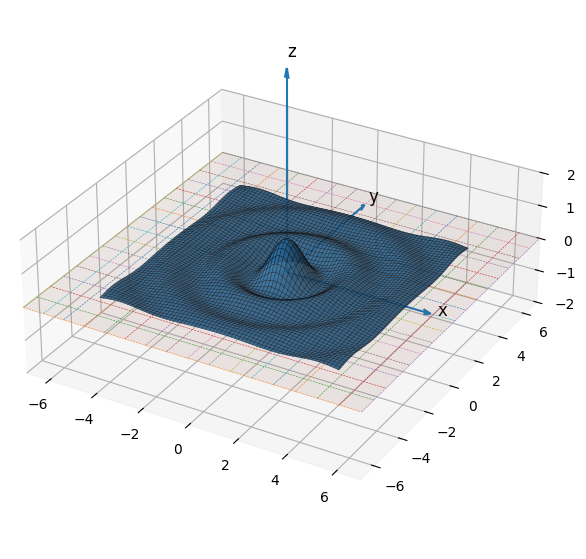

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =======================
#  Superficie de ejemplo
# =======================
x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
Z = np.sinc(R)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# ----- Superficie -----
ax.plot_surface(X, Y, Z, rstride=3, cstride=3,
                linewidth=0.2, edgecolor='k', alpha=0.9)

# =======================
#  Solo plano XY con grid
# =======================
L = 7
grid = np.linspace(-L, L, 17)

# líneas en el plano XY
for yy in grid:
    ax.plot([-L, L], [yy, yy], [0, 0],
            linestyle='--', linewidth=0.4)
for xx in grid:
    ax.plot([xx, xx], [-L, L], [0, 0],
            linestyle='--', linewidth=0.4)

PX, PY = np.meshgrid(grid, grid)
PZ = np.zeros_like(PX)
ax.plot_surface(PX, PY, PZ, alpha=0.12, shade=False)

# =======================
#  Ejes con flechas
# =======================
axis_len = 6
ax.quiver(0, 0, 0, axis_len, 0, 0,
          arrow_length_ratio=0.05)
ax.quiver(0, 0, 0, 0, axis_len, 0,
          arrow_length_ratio=0.05)
ax.quiver(0, 0, 0, 0, 0, axis_len,
          arrow_length_ratio=0.05)

ax.text(axis_len*1.05, 0, 0, 'x', fontsize=12)
ax.text(0, axis_len*1.05, 0, 'y', fontsize=12)
ax.text(0, 0, axis_len*1.05, 'z', fontsize=12)

# =======================
#  Límites y aspecto
# =======================
ax.set_xlim(-L, L)
ax.set_ylim(-L, L)
ax.set_zlim(-2, 2)
ax.set_box_aspect((1, 1, 0.4))

# Ticks “normales” en los ejes
ax.set_xticks(np.arange(-6, 7, 2))
ax.set_yticks(np.arange(-6, 7, 2))
ax.set_zticks(np.arange(-2, 3, 1))

# quitamos las líneas de la caja, pero dejamos los números
ax.xaxis.line.set_linewidth(0)
ax.yaxis.line.set_linewidth(0)
ax.zaxis.line.set_linewidth(0)

plt.show()


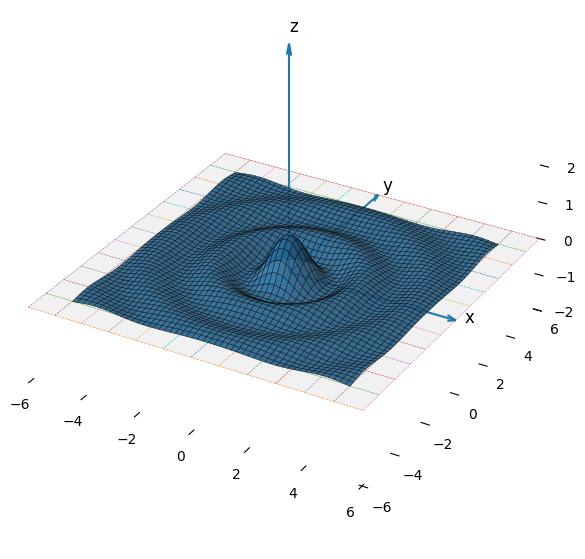

In [9]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =======================
#  Superficie de ejemplo
# =======================
x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
Z = np.sinc(R)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# ----- Superficie -----
ax.plot_surface(X, Y, Z,
                rstride=4, cstride=4,
                linewidth=0.3, edgecolor='k',
                alpha=0.9)

# =======================
#  Piso tipo "infinite grid"
# =======================
L = 6
grid = np.linspace(-L, L, 13)

for yy in grid:
    ax.plot([-L, L], [yy, yy], [0, 0],
            linestyle='--', linewidth=0.4)

for xx in grid:
    ax.plot([xx, xx], [-L, L], [0, 0],
            linestyle='--', linewidth=0.4)

PX, PY = np.meshgrid(grid, grid)
PZ = np.zeros_like(PX)
ax.plot_surface(PX, PY, PZ, alpha=0.10, shade=False)

# =======================
#  Ejes con flechas
# =======================
axis_len = 6
ax.quiver(0, 0, 0, axis_len, 0, 0, arrow_length_ratio=0.05)
ax.quiver(0, 0, 0, 0, axis_len, 0, arrow_length_ratio=0.05)
ax.quiver(0, 0, 0, 0, 0, axis_len, arrow_length_ratio=0.05)

ax.text(axis_len*1.05, 0, 0, 'x', fontsize=12)
ax.text(0, axis_len*1.05, 0, 'y', fontsize=12)
ax.text(0, 0, axis_len*1.05, 'z', fontsize=12)

# =======================
#  Estilo: sin caja, con números
# =======================
ax.set_xlim(-L, L)
ax.set_ylim(-L, L)
ax.set_zlim(-2, 2)
ax.set_box_aspect((1, 1, 0.45))   # "aplanado"

# números normales de matplotlib
ax.set_xticks(np.arange(-6, 7, 2))
ax.set_yticks(np.arange(-6, 7, 2))
ax.set_zticks(np.arange(-2, 3, 1))

# quitar la "caja" y la rejilla 3D interna
ax.grid(False)
ax.xaxis.line.set_linewidth(0)
ax.yaxis.line.set_linewidth(0)
ax.zaxis.line.set_linewidth(0)

# hacer transparentes los planos de fondo
ax.xaxis.pane.set_alpha(0)
ax.yaxis.pane.set_alpha(0)
ax.zaxis.pane.set_alpha(0)

plt.show()


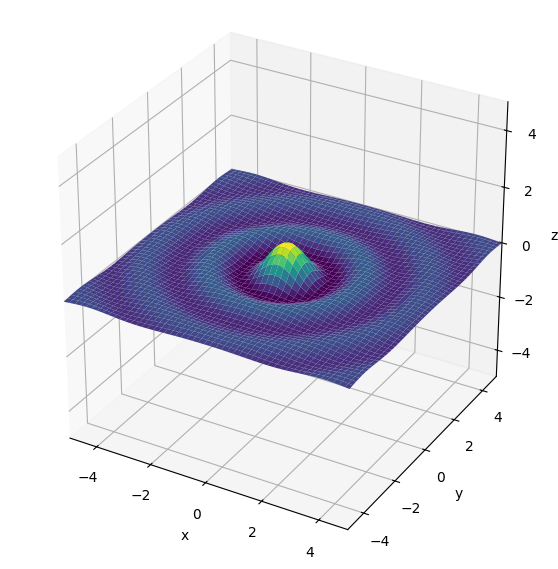

In [10]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
Z = np.sinc(R)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, cmap='viridis')

L = 5
ax.set_xlim(-L, L)
ax.set_ylim(-L, L)
ax.set_zlim(-L, L)
ax.set_box_aspect((1, 1, 1))  # cubo perfecto

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

plt.show()


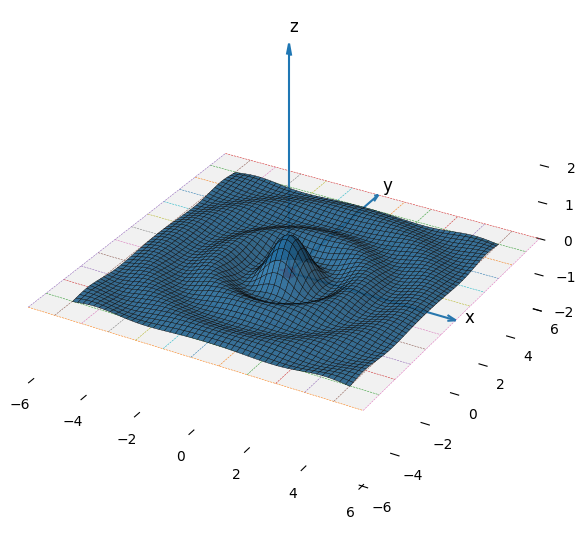

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =======================
#  Superficie de ejemplo
# =======================
x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
Z = np.sinc(R)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# ----- Superficie -----
ax.plot_surface(X, Y, Z,
                rstride=4, cstride=4,
                linewidth=0.3, edgecolor='k',
                alpha=0.9)

# =======================
#  Piso tipo "infinite grid"
# =======================
L = 6
grid = np.linspace(-L, L, 13)

for yy in grid:
    ax.plot([-L, L], [yy, yy], [0, 0],
            linestyle='--', linewidth=0.4)

for xx in grid:
    ax.plot([xx, xx], [-L, L], [0, 0],
            linestyle='--', linewidth=0.4)

PX, PY = np.meshgrid(grid, grid)
PZ = np.zeros_like(PX)
ax.plot_surface(PX, PY, PZ, alpha=0.10, shade=False)

# =======================
#  Ejes con flechas
# =======================
axis_len = 6
ax.quiver(0, 0, 0, axis_len, 0, 0, arrow_length_ratio=0.05)
ax.quiver(0, 0, 0, 0, axis_len, 0, arrow_length_ratio=0.05)
ax.quiver(0, 0, 0, 0, 0, axis_len, arrow_length_ratio=0.05)

ax.text(axis_len*1.05, 0, 0, 'x', fontsize=12)
ax.text(0, axis_len*1.05, 0, 'y', fontsize=12)
ax.text(0, 0, axis_len*1.05, 'z', fontsize=12)

# =======================
#  MARCAR EL ORIGEN
# =======================

# Punto rojo en (0,0,0)
ax.scatter([0], [0], [0], s=60, color='red', zorder=10)

# Cruceta pequeña en el plano XY alrededor del origen
d = 0.3  # longitud de la cruceta
ax.plot([-d, d], [0, 0], [0, 0], color='red', linewidth=1.5)
ax.plot([0, 0], [-d, d], [0, 0], color='red', linewidth=1.5)

# Opcional: una línea vertical pequeña sobre el origen
ax.plot([0, 0], [0, 0], [0, 0.6], color='red', linewidth=1)

# =======================
#  Estilo: sin caja, con números
# =======================
ax.set_xlim(-L, L)
ax.set_ylim(-L, L)
ax.set_zlim(-2, 2)
ax.set_box_aspect((1, 1, 0.45))

ax.set_xticks(np.arange(-6, 7, 2))
ax.set_yticks(np.arange(-6, 7, 2))
ax.set_zticks(np.arange(-2, 3, 1))

ax.grid(False)
ax.xaxis.line.set_linewidth(0)
ax.yaxis.line.set_linewidth(0)
ax.zaxis.line.set_linewidth(0)

ax.xaxis.pane.set_alpha(0)
ax.yaxis.pane.set_alpha(0)
ax.zaxis.pane.set_alpha(0)

plt.show()


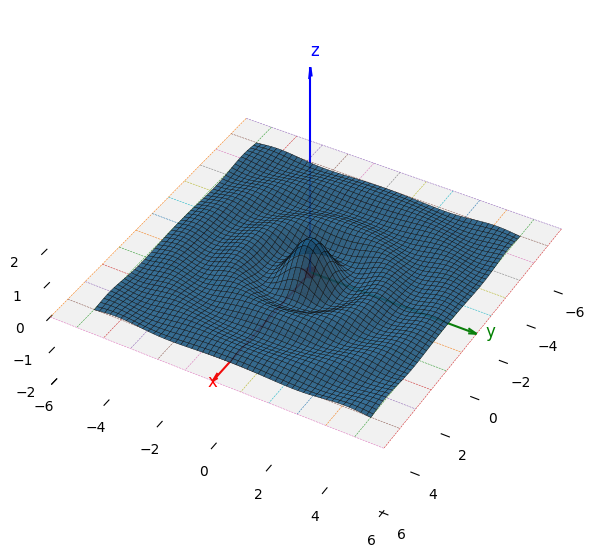

In [27]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =======================
#  Superficie de ejemplo
# =======================
x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
Z = np.sinc(R)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# ----- Superficie -----
ax.plot_surface(X, Y, Z,
                rstride=4, cstride=4,
                linewidth=0.3, edgecolor='k',
                alpha=0.9)

# =======================
#  Piso tipo "infinite grid"
# =======================
L = 6
grid = np.linspace(-L, L, 13)

for yy in grid:
    ax.plot([-L, L], [yy, yy], [0, 0],
            linestyle='--', linewidth=0.4)

for xx in grid:
    ax.plot([xx, xx], [-L, L], [0, 0],
            linestyle='--', linewidth=0.4)

PX, PY = np.meshgrid(grid, grid)
PZ = np.zeros_like(PX)
ax.plot_surface(PX, PY, PZ, alpha=0.10, shade=False)

# =======================
#  Ejes con flechas (colores tipo clásico)
# =======================
axis_len = 6
ax.quiver(0, 0, 0, axis_len, 0, 0,
          arrow_length_ratio=0.05, color='r')  # eje x rojo
ax.quiver(0, 0, 0, 0, axis_len, 0,
          arrow_length_ratio=0.05, color='g')  # eje y verde
ax.quiver(0, 0, 0, 0, 0, axis_len,
          arrow_length_ratio=0.05, color='b')  # eje z azul

ax.text(axis_len*1.05, 0, 0, 'x', fontsize=12, color='r')
ax.text(0, axis_len*1.05, 0, 'y', fontsize=12, color='g')
ax.text(0, 0, axis_len*1.05, 'z', fontsize=12, color='b')

# =======================
#  MARCAR EL ORIGEN
# =======================
ax.scatter([0], [0], [0], s=60, color='red', zorder=10)

d = 0.3  # longitud de la cruceta
ax.plot([-d, d], [0, 0], [0, 0], color='red', linewidth=1.5)
ax.plot([0, 0], [-d, d], [0, 0], color='red', linewidth=1.5)
ax.plot([0, 0], [0, 0], [0, 0.6], color='red', linewidth=1)

# =======================
#  Estilo: sin caja, con números
# =======================
ax.set_xlim(-L, L)
ax.set_ylim(-L, L)
ax.set_zlim(-2, 2)
ax.set_box_aspect((1, 1, 0.45))

ax.set_xticks(np.arange(-6, 7, 2))
ax.set_yticks(np.arange(-6, 7, 2))
ax.set_zticks(np.arange(-2, 3, 1))

ax.grid(False)
ax.xaxis.line.set_linewidth(0)
ax.yaxis.line.set_linewidth(0)
ax.zaxis.line.set_linewidth(0)

ax.xaxis.pane.set_alpha(0)
ax.yaxis.pane.set_alpha(0)
ax.zaxis.pane.set_alpha(0)

# ======== 🔁 ROTAR LA VISTA AQUÍ =========
# Prueba estos valores; deberías ver algo muy parecido
# al dibujito de ejes (z arriba, x a la derecha, y "hacia ti").
ax.view_init(elev=40, azim=30)   # <<< ajusta elev/azim si quieres

plt.show()


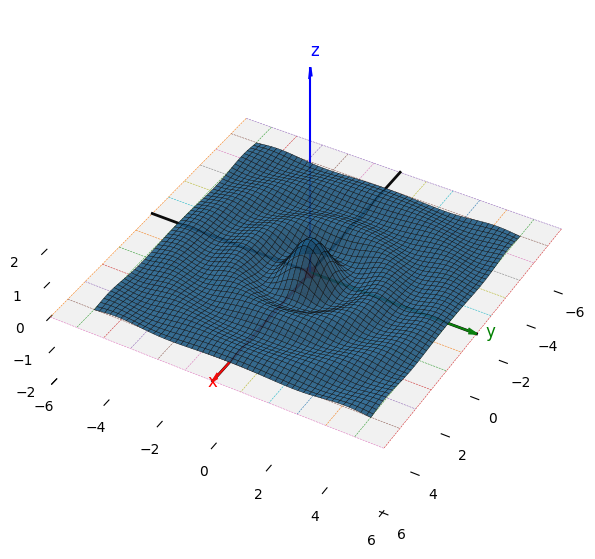

In [28]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =======================
#  Superficie de ejemplo
# =======================
x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
Z = np.sinc(R)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# ----- Superficie -----
ax.plot_surface(X, Y, Z,
                rstride=4, cstride=4,
                linewidth=0.3, edgecolor='k',
                alpha=0.9)

# =======================
#  Piso tipo "infinite grid"
# =======================
L = 6
grid = np.linspace(-L, L, 13)

for yy in grid:
    ax.plot([-L, L], [yy, yy], [0, 0],
            linestyle='--', linewidth=0.4)
for xx in grid:
    ax.plot([xx, xx], [-L, L], [0, 0],
            linestyle='--', linewidth=0.4)

PX, PY = np.meshgrid(grid, grid)
PZ = np.zeros_like(PX)
ax.plot_surface(PX, PY, PZ, alpha=0.10, shade=False)

# ====== LÍNEAS X=0 E Y=0 EN EL PISO (COMPROBACIÓN) ======
ax.plot([-L, L], [0, 0], [0, 0], color='black', linewidth=2)  # eje x sobre el piso
ax.plot([0, 0], [-L, L], [0, 0], color='black', linewidth=2)  # eje y sobre el piso

# =======================
#  Ejes con flechas
# =======================
axis_len = 6
ax.quiver(0, 0, 0, axis_len, 0, 0,
          arrow_length_ratio=0.05, color='r')
ax.quiver(0, 0, 0, 0, axis_len, 0,
          arrow_length_ratio=0.05, color='g')
ax.quiver(0, 0, 0, 0, 0, axis_len,
          arrow_length_ratio=0.05, color='b')

ax.text(axis_len*1.05, 0, 0, 'x', fontsize=12, color='r')
ax.text(0, axis_len*1.05, 0, 'y', fontsize=12, color='g')
ax.text(0, 0, axis_len*1.05, 'z', fontsize=12, color='b')

# =======================
#  MARCAR EL ORIGEN
# =======================
ax.scatter([0], [0], [0], s=60, color='red', zorder=10)

d = 0.3
ax.plot([-d, d], [0, 0], [0, 0], color='red', linewidth=1.5)
ax.plot([0, 0], [-d, d], [0, 0], color='red', linewidth=1.5)
ax.plot([0, 0], [0, 0], [0, 0.6], color='red', linewidth=1)

# =======================
#  Estilo
# =======================
ax.set_xlim(-L, L)
ax.set_ylim(-L, L)
ax.set_zlim(-2, 2)
ax.set_box_aspect((1, 1, 0.45))

ax.set_xticks(np.arange(-6, 7, 2))
ax.set_yticks(np.arange(-6, 7, 2))
ax.set_zticks(np.arange(-2, 3, 1))

ax.grid(False)
ax.xaxis.line.set_linewidth(0)
ax.yaxis.line.set_linewidth(0)
ax.zaxis.line.set_linewidth(0)

ax.xaxis.pane.set_alpha(0)
ax.yaxis.pane.set_alpha(0)
ax.zaxis.pane.set_alpha(0)

# La vista que te gustó
ax.view_init(elev=40, azim=30)

plt.show()


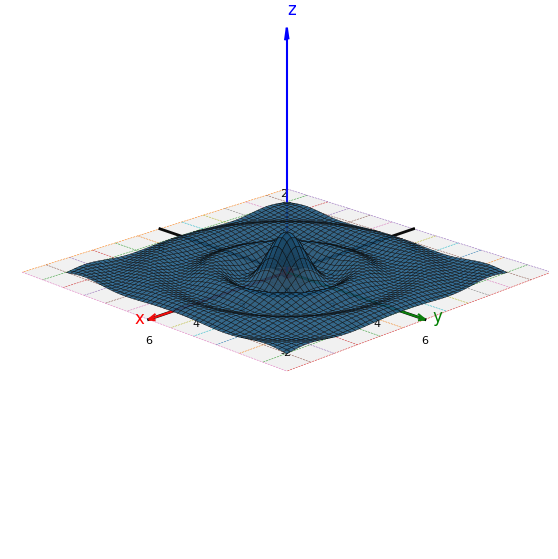

In [50]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =======================
#  Superficie de ejemplo
# =======================
x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
Z = np.sinc(R)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# ----- Superficie -----
ax.plot_surface(X, Y, Z,
                rstride=4, cstride=4,
                linewidth=0.3, edgecolor='k',
                alpha=0.9)

# =======================
#  Piso tipo "infinite grid"
# =======================
L = 6
grid = np.linspace(-L, L, 13)

for yy in grid:
    ax.plot([-L, L], [yy, yy], [0, 0],
            linestyle='--', linewidth=0.4)
for xx in grid:
    ax.plot([xx, xx], [-L, L], [0, 0],
            linestyle='--', linewidth=0.4)

PX, PY = np.meshgrid(grid, grid)
PZ = np.zeros_like(PX)
ax.plot_surface(PX, PY, PZ, alpha=0.10, shade=False)

# ====== LÍNEAS X=0 E Y=0 EN EL PISO (COMPROBACIÓN) ======
ax.plot([-L, L], [0, 0], [0, 0], color='black', linewidth=2)
ax.plot([0, 0], [-L, L], [0, 0], color='black', linewidth=2)

# =======================
#  Ejes con flechas
# =======================
axis_len = 6
ax.quiver(0, 0, 0, axis_len, 0, 0,
          arrow_length_ratio=0.05, color='r')
ax.quiver(0, 0, 0, 0, axis_len, 0,
          arrow_length_ratio=0.05, color='g')
ax.quiver(0, 0, 0, 0, 0, axis_len,
          arrow_length_ratio=0.05, color='b')

ax.text(axis_len*1.1, 0, 0, 'x', fontsize=12, color='r')
ax.text(0, axis_len*1.05, 0, 'y', fontsize=12, color='g')
ax.text(0, 0, axis_len*1.05, 'z', fontsize=12, color='b')

# =======================
#  MARCAR EL ORIGEN
# =======================
ax.scatter([0], [0], [0], s=60, color='red', zorder=10)
d = 0.3
ax.plot([-d, d], [0, 0], [0, 0], color='red', linewidth=1.5)
ax.plot([0, 0], [-d, d], [0, 0], color='red', linewidth=1.5)
ax.plot([0, 0], [0, 0], [0, 0.6], color='red', linewidth=1)

# =======================
#  Estilo
# =======================
ax.set_xlim(-L, L)
ax.set_ylim(-L, L)
ax.set_zlim(-2, 2)
ax.set_box_aspect((1, 1, 0.45))

# Ocultamos ticks "reales"
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

ax.grid(False)
ax.xaxis.line.set_linewidth(0)
ax.yaxis.line.set_linewidth(0)
ax.zaxis.line.set_linewidth(0)

ax.xaxis.pane.set_alpha(0)
ax.yaxis.pane.set_alpha(0)
ax.zaxis.pane.set_alpha(0)

# ====== NÚMEROS MANUALES SOBRE EL PISO ======
ticks = np.arange(-6, 7, 2)

# números en eje x sobre el piso
for t in ticks:
    ax.text(t, 0, -0.4, f"{t}",
            ha='center', va='top', fontsize=8)

# números en eje y sobre el piso
for t in ticks:
    ax.text(0, t, -0.4, f"{t}",
            ha='center', va='top', fontsize=8)

# números en eje z a un lado del eje
for t in np.arange(-2, 3, 1):
    ax.text(0.3, 0, t, f"{t}",
            ha='left', va='center', fontsize=8)

# Vista que te gusta
ax.view_init(elev=20, azim=45)

plt.show()


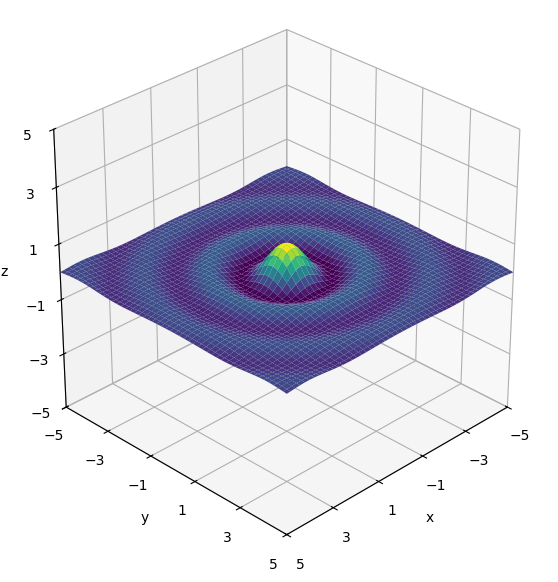

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =======================
#  Superficie de ejemplo
# =======================
x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
Z = np.sinc(R)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# ----- Superficie -----
ax.plot_surface(X, Y, Z,
                rstride=4, cstride=4,
                linewidth=0.3, edgecolor='k',
                alpha=0.9)

# =======================
#  Piso tipo "infinite grid"
# =======================
L = 6
grid = np.linspace(-L, L, 13)

for yy in grid:
    ax.plot([-L, L], [yy, yy], [0, 0],
            linestyle='--', linewidth=0.4)
for xx in grid:
    ax.plot([xx, xx], [-L, L], [0, 0],
            linestyle='--', linewidth=0.4)

PX, PY = np.meshgrid(grid, grid)
PZ = np.zeros_like(PX)
ax.plot_surface(PX, PY, PZ, alpha=0.10, shade=False)

# ====== LÍNEAS X=0 E Y=0 EN EL PISO (COMPROBACIÓN) ======
ax.plot([-L, L], [0, 0], [0, 0], color='black', linewidth=2)
ax.plot([0, 0], [-L, L], [0, 0], color='black', linewidth=2)

# =======================
#  Ejes con flechas
# =======================
axis_len = 6
ax.quiver(0, 0, 0, axis_len, 0, 0,
          arrow_length_ratio=0.05, color='r')
ax.quiver(0, 0, 0, 0, axis_len, 0,
          arrow_length_ratio=0.05, color='g')
ax.quiver(0, 0, 0, 0, 0, axis_len,
          arrow_length_ratio=0.05, color='b')

ax.text(axis_len*1.05, 0, 0, 'x', fontsize=12, color='r')
ax.text(0, axis_len*1.05, 0, 'y', fontsize=12, color='g')
ax.text(0, 0, axis_len*1.05, 'z', fontsize=12, color='b')

# =======================
#  MARCAR EL ORIGEN
# =======================
ax.scatter([0], [0], [0], s=60, color='red', zorder=10)
d = 0.3
ax.plot([-d, d], [0, 0], [0, 0], color='red', linewidth=1.5)
ax.plot([0, 0], [-d, d], [0, 0], color='red', linewidth=1.5)
ax.plot([0, 0], [0, 0], [0, 0.6], color='red', linewidth=1)

# =======================
#  Estilo
# =======================
ax.set_xlim(-L, L)
ax.set_ylim(-L, L)
ax.set_zlim(-2, 2)
ax.set_box_aspect((1, 1, 0.45))

# Ocultamos ticks "reales"
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

ax.grid(False)
ax.xaxis.line.set_linewidth(0)
ax.yaxis.line.set_linewidth(0)
ax.zaxis.line.set_linewidth(0)

ax.xaxis.pane.set_alpha(0)
ax.yaxis.pane.set_alpha(0)
ax.zaxis.pane.set_alpha(0)

# ====== NÚMEROS MANUALES SOBRE EL PISO ======
ticks = np.arange(-6, 7, 2)

# números en eje x sobre el piso
for t in ticks:
    ax.text(t, 0, -0.4, f"{t}",
            ha='center', va='top', fontsize=8)

# números en eje y sobre el piso
for t in ticks:
    ax.text(0, t, -0.4, f"{t}",
            ha='center', va='top', fontsize=8)

# números en eje z a un lado del eje
for t in np.arange(-2, 3, 1):
    ax.text(0.3, 0, t, f"{t}",
            ha='left', va='center', fontsize=8)

# Vista que te gusta
ax.view_init(elev=40, azim=30)

plt.show()
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
Z = np.sinc(R)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, Y, Z, cmap='viridis')

L = 5
ax.set_xlim(-L, L)
ax.set_ylim(-L, L)
ax.set_zlim(-L, L)
ax.set_box_aspect((1, 1, 1))   # cubo perfecto

ax.set_xticks(np.arange(-5, 6, 2))
ax.set_yticks(np.arange(-5, 6, 2))
ax.set_zticks(np.arange(-5, 6, 2))

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_zlabel('z')

ax.view_init(elev=30, azim=45)
plt.show()


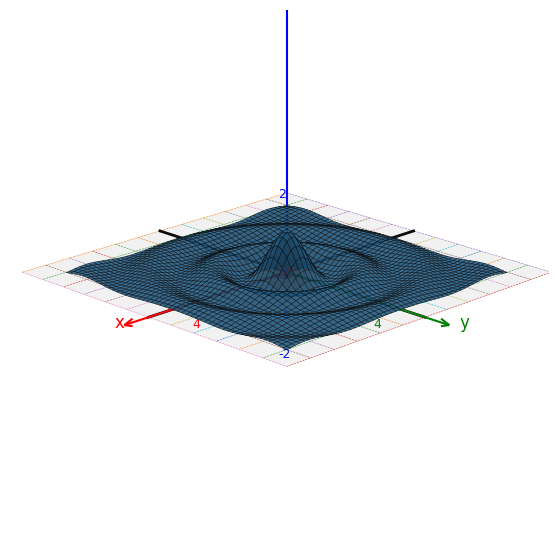

In [48]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =======================
#  Superficie de ejemplo
# =======================
x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
Z = np.sinc(R)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# ----- Superficie -----
ax.plot_surface(X, Y, Z,
                rstride=4, cstride=4,
                linewidth=0.3, edgecolor='k',
                alpha=0.9)

# =======================
#  Piso tipo "infinite grid"
# =======================
L = 6                   # alcance del piso
grid = np.linspace(-L, L, 13)

for yy in grid:
    ax.plot([-L, L], [yy, yy], [0, 0],
            linestyle='--', linewidth=0.4)
for xx in grid:
    ax.plot([xx, xx], [-L, L], [0, 0],
            linestyle='--', linewidth=0.4)

PX, PY = np.meshgrid(grid, grid)
PZ = np.zeros_like(PX)
ax.plot_surface(PX, PY, PZ, alpha=0.10, shade=False)

# ====== LÍNEAS X=0 E Y=0 EN EL PISO ======
ax.plot([-L, L], [0, 0], [0, 0], color='black', linewidth=2)
ax.plot([0, 0], [-L, L], [0, 0], color='black', linewidth=2)

# =======================
#  Ejes con flechas
# =======================
axis_len = 7            # flechas un poco más largas que el piso

ax.quiver(0, 0, 0, axis_len, 0, 0,
          arrow_length_ratio=0.05, color='r')
ax.quiver(0, 0, 0, 0, axis_len, 0,
          arrow_length_ratio=0.05, color='g')
ax.quiver(0, 0, 0, 0, 0, axis_len,
          arrow_length_ratio=0.05, color='b')

# etiquetas de ejes un poco MÁS ALLÁ de la punta
ax.text(axis_len+0.4, 0, 0, 'x', fontsize=12, color='r')
ax.text(0, axis_len+0.4, 0, 'y', fontsize=12, color='g')
ax.text(0, 0, axis_len+0.4, 'z', fontsize=12, color='b')

# =======================
#  MARCAR EL ORIGEN
# =======================
ax.scatter([0], [0], [0], s=60, color='red', zorder=10)
d = 0.3
ax.plot([-d, d], [0, 0], [0, 0], color='red', linewidth=1.5)
ax.plot([0, 0], [-d, d], [0, 0], color='red', linewidth=1.5)
ax.plot([0, 0], [0, 0], [0, 0.6], color='red', linewidth=1)

# =======================
#  Estilo
# =======================
ax.set_xlim(-L, L)
ax.set_ylim(-L, L)
ax.set_zlim(-2, 2)
ax.set_box_aspect((1, 1, 0.45))

# Ocultamos ticks "reales"
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

ax.grid(False)
ax.xaxis.line.set_linewidth(0)
ax.yaxis.line.set_linewidth(0)
ax.zaxis.line.set_linewidth(0)

ax.xaxis.pane.set_alpha(0)
ax.yaxis.pane.set_alpha(0)
ax.zaxis.pane.set_alpha(0)

# ====== NÚMEROS MANUALES ======
ticks_xy = np.array([-4, 0, 4])      # referencias en x,y
ticks_z  = np.array([-2, -1, 0, 1, 2])

# x: sobre el piso, color del eje
for t in ticks_xy:
    ax.text(t, 0, -0.4, f"{t}",
            ha='center', va='top', fontsize=9, color='r')

# y: sobre el piso, color del eje
for t in ticks_xy:
    ax.text(0, t, -0.4, f"{t}",
            ha='center', va='top', fontsize=9, color='g')

# z: al lado del eje z, color azul
for t in ticks_z:
    ax.text(0.4, 0, t, f"{t}",
            ha='left', va='center', fontsize=9, color='b')

# Vista que te gusta
ax.view_init(elev=19, azim=45)

plt.show()


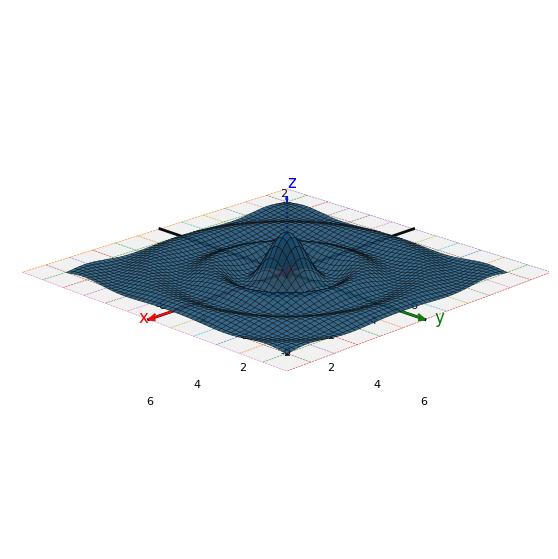

In [51]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =======================
#  Superficie de ejemplo
# =======================
x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
Z = np.sinc(R)

fig = plt.figure(figsize=(7, 7))
ax = fig.add_subplot(111, projection='3d')

# ----- Superficie -----
ax.plot_surface(X, Y, Z,
                rstride=4, cstride=4,
                linewidth=0.3, edgecolor='k',
                alpha=0.9)

# =======================
#  Piso tipo "infinite grid"
# =======================
L = 6
grid = np.linspace(-L, L, 13)

for yy in grid:
    ax.plot([-L, L], [yy, yy], [0, 0],
            linestyle='--', linewidth=0.4)
for xx in grid:
    ax.plot([xx, xx], [-L, L], [0, 0],
            linestyle='--', linewidth=0.4)

PX, PY = np.meshgrid(grid, grid)
PZ = np.zeros_like(PX)
ax.plot_surface(PX, PY, PZ, alpha=0.10, shade=False)

# ====== LÍNEAS X=0 E Y=0 EN EL PISO ======
ax.plot([-L, L], [0, 0], [0, 0], color='black', linewidth=2)
ax.plot([0, 0], [-L, L], [0, 0], color='black', linewidth=2)

# =======================
#  Ejes con flechas
# =======================
axis_len_xy = L          # x e y hasta el borde del piso
zmin, zmax = -2, 2
axis_len_z  = zmax * 0.95   # z un poco debajo del techo del cubo

ax.quiver(0, 0, 0, axis_len_xy, 0, 0,
          arrow_length_ratio=0.05, color='r')   # eje x
ax.quiver(0, 0, 0, 0, axis_len_xy, 0,
          arrow_length_ratio=0.05, color='g')   # eje y
ax.quiver(0, 0, 0, 0, 0, axis_len_z,
          arrow_length_ratio=0.05, color='b')   # eje z dentro de zlim

# etiquetas un poco más allá de la punta
ax.text(axis_len_xy+0.4, 0, 0, 'x', fontsize=12, color='r')
ax.text(0, axis_len_xy+0.4, 0, 'y', fontsize=12, color='g')
ax.text(0, 0, axis_len_z+0.2, 'z', fontsize=12, color='b')

# =======================
#  MARCAR EL ORIGEN
# =======================
ax.scatter([0], [0], [0], s=60, color='red', zorder=10)
d = 0.3
ax.plot([-d, d], [0, 0], [0, 0], color='red', linewidth=1.5)
ax.plot([0, 0], [-d, d], [0, 0], color='red', linewidth=1.5)
ax.plot([0, 0], [0, 0], [0, 0.6], color='red', linewidth=1)

# =======================
#  Estilo
# =======================
ax.set_xlim(-L, L)
ax.set_ylim(-L, L)
ax.set_zlim(zmin, zmax)
ax.set_box_aspect((1, 1, 0.45))

ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

ax.grid(False)
ax.xaxis.line.set_linewidth(0)
ax.yaxis.line.set_linewidth(0)
ax.zaxis.line.set_linewidth(0)

ax.xaxis.pane.set_alpha(0)
ax.yaxis.pane.set_alpha(0)
ax.zaxis.pane.set_alpha(0)

# ====== NÚMEROS MANUALES SOBRE EL PISO ======
ticks = np.arange(-6, 7, 2)

for t in ticks:
    ax.text(t, 0, zmin+0.1, f"{t}",
            ha='center', va='top', fontsize=8)
for t in ticks:
    ax.text(0, t, zmin+0.1, f"{t}",
            ha='center', va='top', fontsize=8)

for t in np.arange(-2, 3, 1):
    ax.text(0.3, 0, t, f"{t}",
            ha='left', va='center', fontsize=8)

# Vista
ax.view_init(elev=20, azim=45)

plt.show()


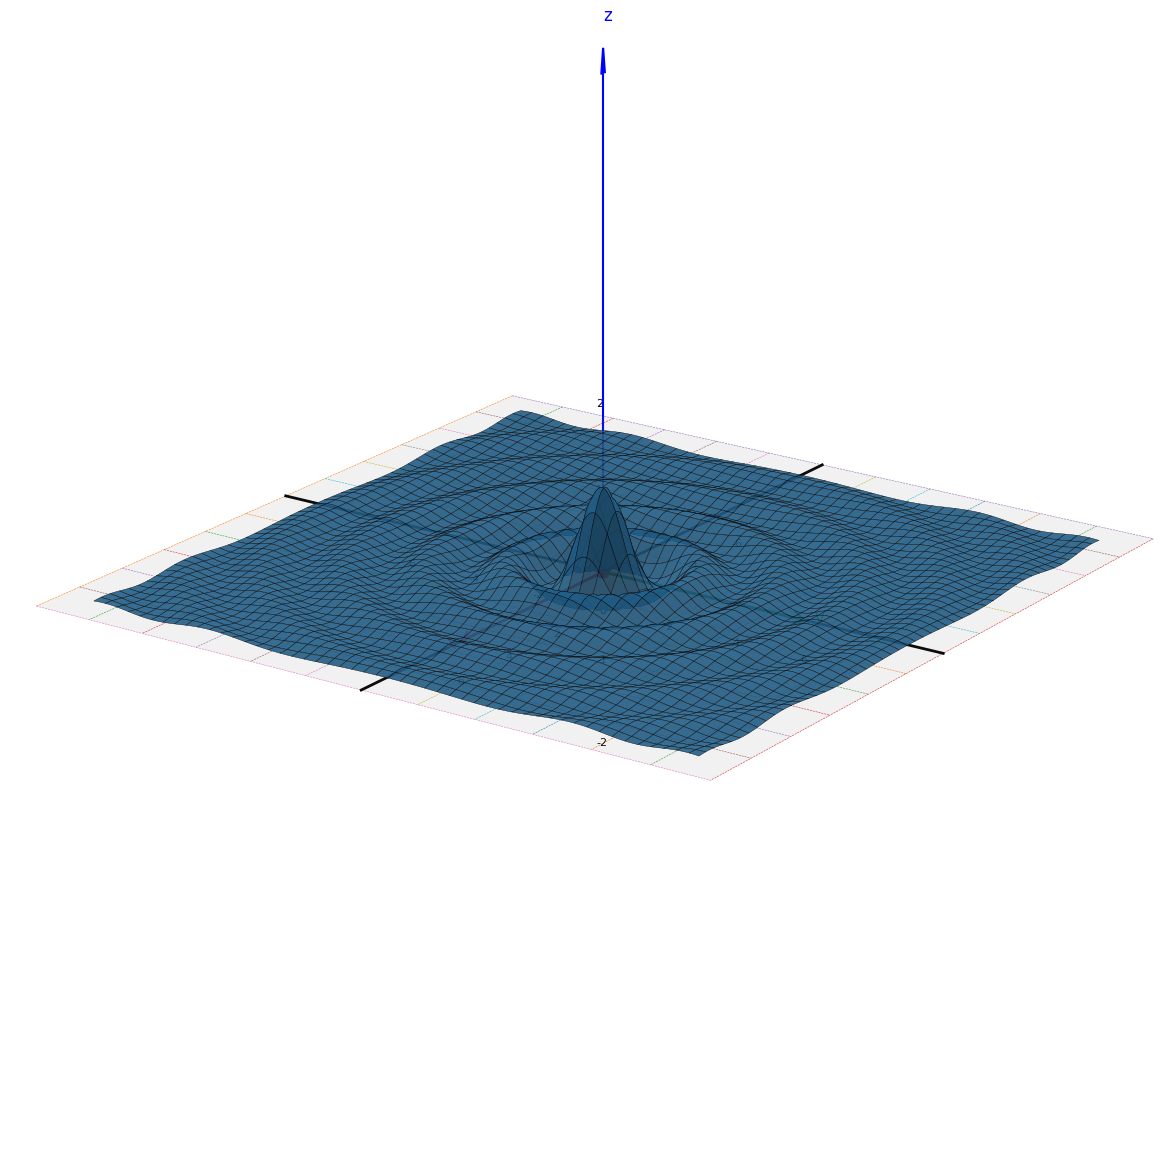

In [54]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =======================
#  Superficie de ejemplo
# =======================
x = np.linspace(-9, 9, 200)
y = np.linspace(-9, 9, 200)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
Z = np.sinc(R)

fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection='3d')

# ----- Superficie -----
ax.plot_surface(X, Y, Z,
                rstride=4, cstride=4,
                linewidth=0.3, edgecolor='k',
                alpha=0.9)

# =======================
#  Piso tipo "infinite grid"
# =======================
L = 10
grid = np.linspace(-L, L, 13)

for yy in grid:
    ax.plot([-L, L], [yy, yy], [0, 0],
            linestyle='--', linewidth=0.4)
for xx in grid:
    ax.plot([xx, xx], [-L, L], [0, 0],
            linestyle='--', linewidth=0.4)

PX, PY = np.meshgrid(grid, grid)
PZ = np.zeros_like(PX)
ax.plot_surface(PX, PY, PZ, alpha=0.10, shade=False)

# ====== LÍNEAS X=0 E Y=0 EN EL PISO (COMPROBACIÓN) ======
ax.plot([-L, L], [0, 0], [0, 0], color='black', linewidth=2)
ax.plot([0, 0], [-L, L], [0, 0], color='black', linewidth=2)

# =======================
#  Ejes con flechas
# =======================
axis_len = 6
ax.quiver(0, 0, 0, axis_len, 0, 0,
          arrow_length_ratio=0.05, color='r')
ax.quiver(0, 0, 0, 0, axis_len, 0,
          arrow_length_ratio=0.05, color='g')
ax.quiver(0, 0, 0, 0, 0, axis_len,
          arrow_length_ratio=0.05, color='b')

ax.text(axis_len*1.1, 0, 0, 'x', fontsize=12, color='r')
ax.text(0, axis_len*1.05, 0, 'y', fontsize=12, color='g')
ax.text(0, 0, axis_len*1.05, 'z', fontsize=12, color='b')

# =======================
#  MARCAR EL ORIGEN
# =======================
ax.scatter([0], [0], [0], s=60, color='red', zorder=10)
d = 0.3
ax.plot([-d, d], [0, 0], [0, 0], color='red', linewidth=1.5)
ax.plot([0, 0], [-d, d], [0, 0], color='red', linewidth=1.5)
ax.plot([0, 0], [0, 0], [0, 0.6], color='red', linewidth=1)

# =======================
#  Estilo
# =======================
ax.set_xlim(-L, L)
ax.set_ylim(-L, L)
ax.set_zlim(-2, 2)
ax.set_box_aspect((1, 1, 0.45))

# Ocultamos ticks "reales"
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

ax.grid(False)
ax.xaxis.line.set_linewidth(0)
ax.yaxis.line.set_linewidth(0)
ax.zaxis.line.set_linewidth(0)

ax.xaxis.pane.set_alpha(0)
ax.yaxis.pane.set_alpha(0)
ax.zaxis.pane.set_alpha(0)

# ====== NÚMEROS MANUALES SOBRE EL PISO ======
ticks = np.arange(-6, 7, 2)

# números en eje x sobre el piso
for t in ticks:
    ax.text(t, 0, -0.4, f"{t}",
            ha='center', va='top', fontsize=8)

# números en eje y sobre el piso
for t in ticks:
    ax.text(0, t, -0.4, f"{t}",
            ha='center', va='top', fontsize=8)

# números en eje z a un lado del eje
for t in np.arange(-2, 3, 1):
    ax.text(0.3, 0, t, f"{t}",
            ha='left', va='center', fontsize=8)

# Vista que te gusta
ax.view_init(elev=20, azim=35)

plt.show()

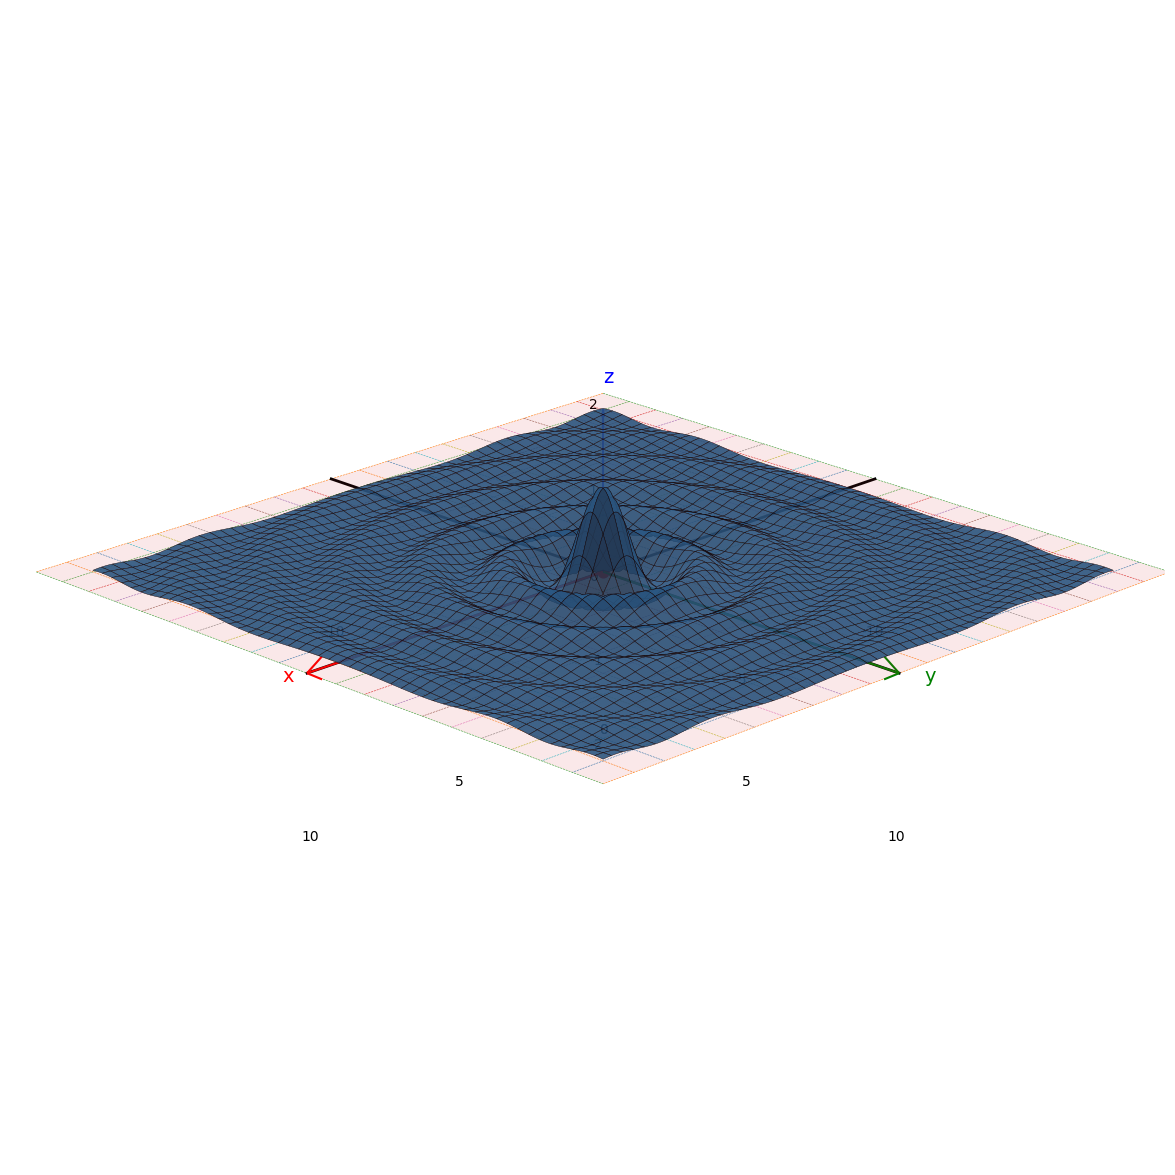

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =======================
#  Superficie de ejemplo
# =======================
x = np.linspace(-9, 9, 200)
y = np.linspace(-9, 9, 200)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
Z = np.sinc(R)

fig = plt.figure(figsize=(15, 15))
ax = fig.add_subplot(111, projection='3d')

# ----- Superficie -----
ax.plot_surface(X, Y, Z,
                rstride=4, cstride=4,
                linewidth=0.3, edgecolor='k',
                alpha=0.9)

# =======================
#  Piso tipo "infinite grid"
# =======================
L = 10                      # ahora piso de -10 a 10
grid = np.linspace(-L, L, 21)

for yy in grid:
    ax.plot([-L, L], [yy, yy], [0, 0],
            linestyle='--', linewidth=0.4)
for xx in grid:
    ax.plot([xx, xx], [-L, L], [0, 0],
            linestyle='--', linewidth=0.4)

PX, PY = np.meshgrid(grid, grid)
PZ = np.zeros_like(PX)
ax.plot_surface(PX, PY, PZ, alpha=0.10, shade=False)

# ====== LÍNEAS X=0 E Y=0 EN EL PISO ======
ax.plot([-L, L], [0, 0], [0, 0], color='black', linewidth=2)
ax.plot([0, 0], [-L, L], [0, 0], color='black', linewidth=2)

# =======================
#  Ejes con flechas
# =======================
axis_len_xy = L              # x,y hasta el borde del piso
zmin, zmax = -2, 2
axis_len_z  = zmax * 0.95    # z un poco por debajo del techo

ax.quiver(0, 0, 0, axis_len_xy, 0, 0,
          arrow_length_ratio=0.05, color='r')
ax.quiver(0, 0, 0, 0, axis_len_xy, 0,
          arrow_length_ratio=0.05, color='g')
ax.quiver(0, 0, 0, 0, 0, axis_len_z,
          arrow_length_ratio=0.05, color='b')

ax.text(axis_len_xy+0.8, 0, 0, 'x', fontsize=14, color='r')
ax.text(0, axis_len_xy+0.8, 0, 'y', fontsize=14, color='g')
ax.text(0, 0, axis_len_z+0.3, 'z', fontsize=14, color='b')

# =======================
#  MARCAR EL ORIGEN
# =======================
ax.scatter([0], [0], [0], s=60, color='red', zorder=10)
d = 0.4
ax.plot([-d, d], [0, 0], [0, 0], color='red', linewidth=1.5)
ax.plot([0, 0], [-d, d], [0, 0], color='red', linewidth=1.5)
ax.plot([0, 0], [0, 0], [0, 0.8], color='red', linewidth=1)

# =======================
#  Estilo
# =======================
ax.set_xlim(-L, L)
ax.set_ylim(-L, L)
ax.set_zlim(zmin, zmax)
ax.set_box_aspect((1, 1, 0.45))

ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

ax.grid(False)
ax.xaxis.line.set_linewidth(0)
ax.yaxis.line.set_linewidth(0)
ax.zaxis.line.set_linewidth(0)

ax.xaxis.pane.set_alpha(0)
ax.yaxis.pane.set_alpha(0)
ax.zaxis.pane.set_alpha(0)

# ====== NÚMEROS MANUALES SOBRE EL PISO ======
ticks_xy = np.arange(-10, 11, 5)   # por ejemplo: -10, -5, 0, 5, 10

for t in ticks_xy:
    ax.text(t, 0, zmin+0.2, f"{t}",
            ha='center', va='top', fontsize=10)
for t in ticks_xy:
    ax.text(0, t, zmin+0.2, f"{t}",
            ha='center', va='top', fontsize=10)

for t in np.arange(-2, 3, 1):
    ax.text(0.5, 0, t, f"{t}",
            ha='left', va='center', fontsize=10)

# Vista
ax.view_init(elev=20, azim=45)

plt.show()


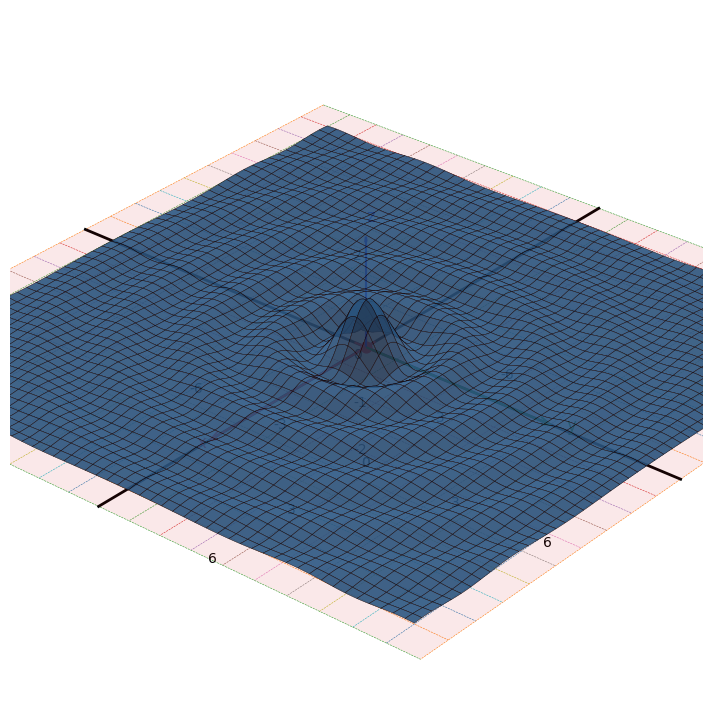

In [56]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =======================
#  Superficie de ejemplo
# =======================
x = np.linspace(-9, 9, 200)
y = np.linspace(-9, 9, 200)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
Z = np.sinc(R)

fig = plt.figure(figsize=(9, 9))
ax = fig.add_subplot(111, projection='3d')

# ----- Superficie -----
ax.plot_surface(X, Y, Z,
                rstride=4, cstride=4,
                linewidth=0.3, edgecolor='k',
                alpha=0.9)

# =======================
#  Plano "infinito"
# =======================
L_plane = 10          # hasta dónde llega la cuadrícula
grid = np.linspace(-L_plane, L_plane, 21)

for yy in grid:
    ax.plot([-L_plane, L_plane], [yy, yy], [0, 0],
            linestyle='--', linewidth=0.4)
for xx in grid:
    ax.plot([xx, xx], [-L_plane, L_plane], [0, 0],
            linestyle='--', linewidth=0.4)

PX, PY = np.meshgrid(grid, grid)
PZ = np.zeros_like(PX)
ax.plot_surface(PX, PY, PZ, alpha=0.10, shade=False)

# ====== LÍNEAS X=0 E Y=0 EN EL PISO ======
ax.plot([-L_plane, L_plane], [0, 0], [0, 0], color='black', linewidth=2)
ax.plot([0, 0], [-L_plane, L_plane], [0, 0], color='black', linewidth=2)

# =======================
#  Ejes con flechas
# =======================
L_view = 6            # cuánto queremos ver en la cámara
zmin, zmax = -2.5, 2.5
axis_len_xy = L_view
axis_len_z  = zmax * 0.9

ax.quiver(0, 0, 0, axis_len_xy, 0, 0,
          arrow_length_ratio=0.05, color='r')
ax.quiver(0, 0, 0, 0, axis_len_xy, 0,
          arrow_length_ratio=0.05, color='g')
ax.quiver(0, 0, 0, 0, 0, axis_len_z,
          arrow_length_ratio=0.05, color='b')

ax.text(axis_len_xy+0.5, 0, 0, 'x', fontsize=12, color='r')
ax.text(0, axis_len_xy+0.5, 0, 'y', fontsize=12, color='g')
ax.text(0, 0, axis_len_z+0.3, 'z', fontsize=12, color='b')

# =======================
#  ORIGEN
# =======================
ax.scatter([0], [0], [0], s=60, color='red', zorder=10)
d = 0.35
ax.plot([-d, d], [0, 0], [0, 0], color='red', linewidth=1.5)
ax.plot([0, 0], [-d, d], [0, 0], color='red', linewidth=1.5)
ax.plot([0, 0], [0, 0], [0, 0.8], color='red', linewidth=1)

# =======================
#  Estilo y límites de la CÁMARA
# =======================
ax.set_xlim(-L_view, L_view)
ax.set_ylim(-L_view, L_view)
ax.set_zlim(zmin, zmax)
ax.set_box_aspect((1, 1, 0.6))   # un poco más alto

ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

ax.grid(False)
ax.xaxis.line.set_linewidth(0)
ax.yaxis.line.set_linewidth(0)
ax.zaxis.line.set_linewidth(0)

ax.xaxis.pane.set_alpha(0)
ax.yaxis.pane.set_alpha(0)
ax.zaxis.pane.set_alpha(0)

# ====== NÚMEROS MANUALES ======
ticks_xy = np.arange(-6, 7, 3)

for t in ticks_xy:
    ax.text(t, 0, zmin+0.2, f"{t}",
            ha='center', va='top', fontsize=10)
for t in ticks_xy:
    ax.text(0, t, zmin+0.2, f"{t}",
            ha='center', va='top', fontsize=10)

for t in np.arange(-2, 3, 1):
    ax.text(0.5, 0, t, f"{t}",
            ha='left', va='center', fontsize=10)

# Vista
ax.view_init(elev=30, azim=40)

plt.show()


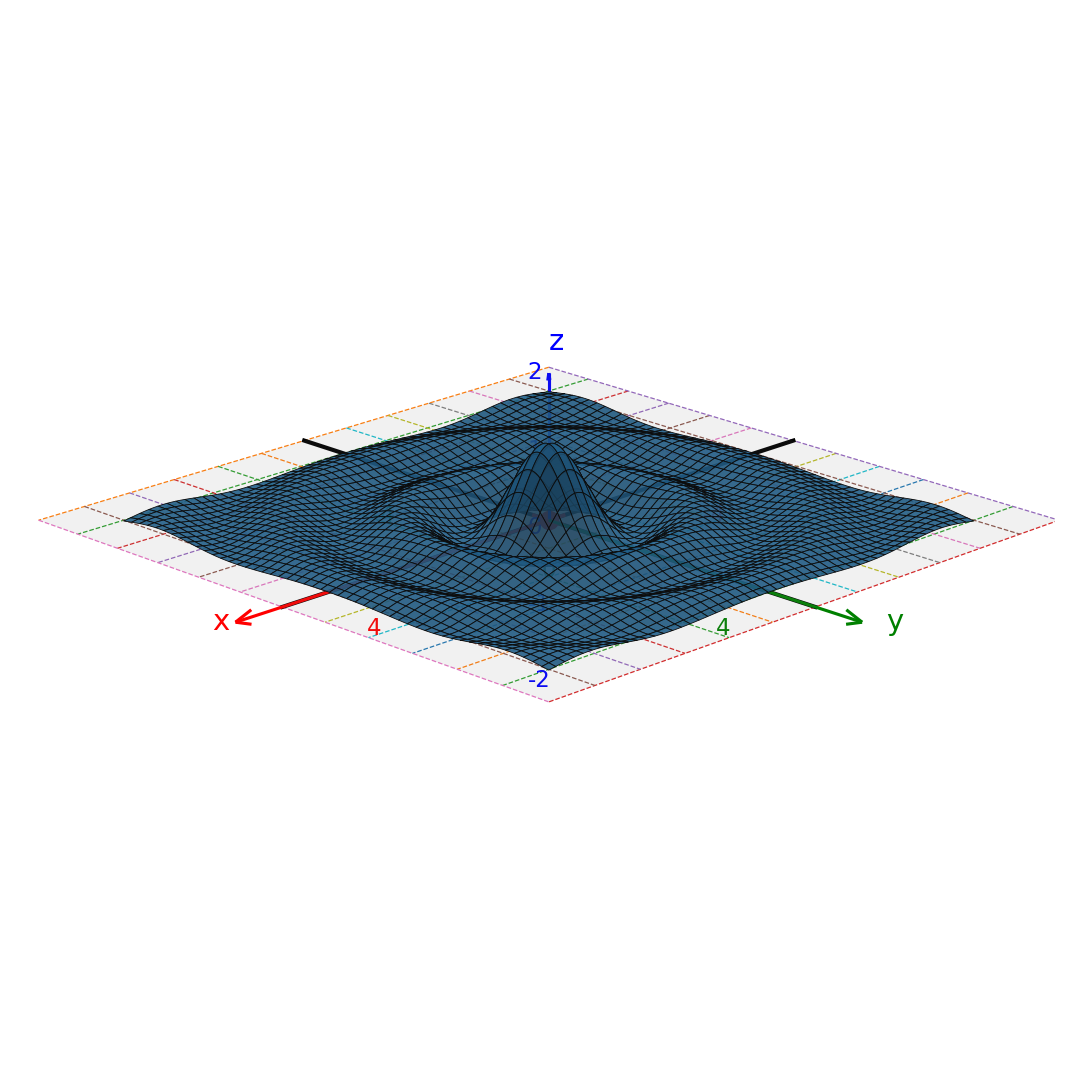

In [57]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =======================
#  Superficie de ejemplo
# =======================
x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
Z = np.sinc(R)

# Figura más grande y con mejor resolución
fig = plt.figure(figsize=(9, 9), dpi=150)
ax = fig.add_subplot(111, projection='3d')

# ----- Superficie -----
ax.plot_surface(X, Y, Z,
                rstride=4, cstride=4,
                linewidth=0.4, edgecolor='k',
                alpha=0.9)

# =======================
#  Piso tipo "infinite grid"
# =======================
L = 6                   # alcance del piso
grid = np.linspace(-L, L, 13)

for yy in grid:
    ax.plot([-L, L], [yy, yy], [0, 0],
            linestyle='--', linewidth=0.6)
for xx in grid:
    ax.plot([xx, xx], [-L, L], [0, 0],
            linestyle='--', linewidth=0.6)

PX, PY = np.meshgrid(grid, grid)
PZ = np.zeros_like(PX)
ax.plot_surface(PX, PY, PZ, alpha=0.10, shade=False)

# ====== LÍNEAS X=0 E Y=0 EN EL PISO ======
ax.plot([-L, L], [0, 0], [0, 0], color='black', linewidth=2)
ax.plot([0, 0], [-L, L], [0, 0], color='black', linewidth=2)

# =======================
#  Ejes con flechas
# =======================
axis_len_xy = 7         # x,y un poco más largos que el piso
axis_len_z  = 1.9       # z dentro de zlim (-2,2)

ax.quiver(0, 0, 0, axis_len_xy, 0, 0,
          arrow_length_ratio=0.05, color='r')
ax.quiver(0, 0, 0, 0, axis_len_xy, 0,
          arrow_length_ratio=0.05, color='g')
ax.quiver(0, 0, 0, 0, 0, axis_len_z,
          arrow_length_ratio=0.05, color='b')

# etiquetas de ejes un poco MÁS ALLÁ de la punta
ax.text(axis_len_xy+0.5, 0, 0, 'x', fontsize=14, color='r')
ax.text(0, axis_len_xy+0.5, 0, 'y', fontsize=14, color='g')
ax.text(0, 0, axis_len_z+0.3, 'z', fontsize=14, color='b')

# =======================
#  MARCAR EL ORIGEN
# =======================
ax.scatter([0], [0], [0], s=70, color='red', zorder=10)
d = 0.35
ax.plot([-d, d], [0, 0], [0, 0], color='red', linewidth=1.8)
ax.plot([0, 0], [-d, d], [0, 0], color='red', linewidth=1.8)
ax.plot([0, 0], [0, 0], [0, 0.8], color='red', linewidth=1.8)

# =======================
#  Estilo
# =======================
ax.set_xlim(-L, L)
ax.set_ylim(-L, L)
ax.set_zlim(-2, 2)
ax.set_box_aspect((1, 1, 0.45))

# Ocultamos ticks "reales"
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

ax.grid(False)
ax.xaxis.line.set_linewidth(0)
ax.yaxis.line.set_linewidth(0)
ax.zaxis.line.set_linewidth(0)

ax.xaxis.pane.set_alpha(0)
ax.yaxis.pane.set_alpha(0)
ax.zaxis.pane.set_alpha(0)

# ====== NÚMEROS MANUALES ======
ticks_xy = np.array([-4, 0, 4])      # referencias en x,y
ticks_z  = np.array([-2, -1, 0, 1, 2])

# x: sobre el piso, color del eje
for t in ticks_xy:
    ax.text(t, 0, -0.5, f"{t}",
            ha='center', va='top', fontsize=11, color='r')

# y: sobre el piso, color del eje
for t in ticks_xy:
    ax.text(0, t, -0.5, f"{t}",
            ha='center', va='top', fontsize=11, color='g')

# z: al lado del eje z, color azul
for t in ticks_z:
    ax.text(0.5, 0, t, f"{t}",
            ha='left', va='center', fontsize=11, color='b')

# Vista
ax.view_init(elev=19, azim=45)

plt.show()


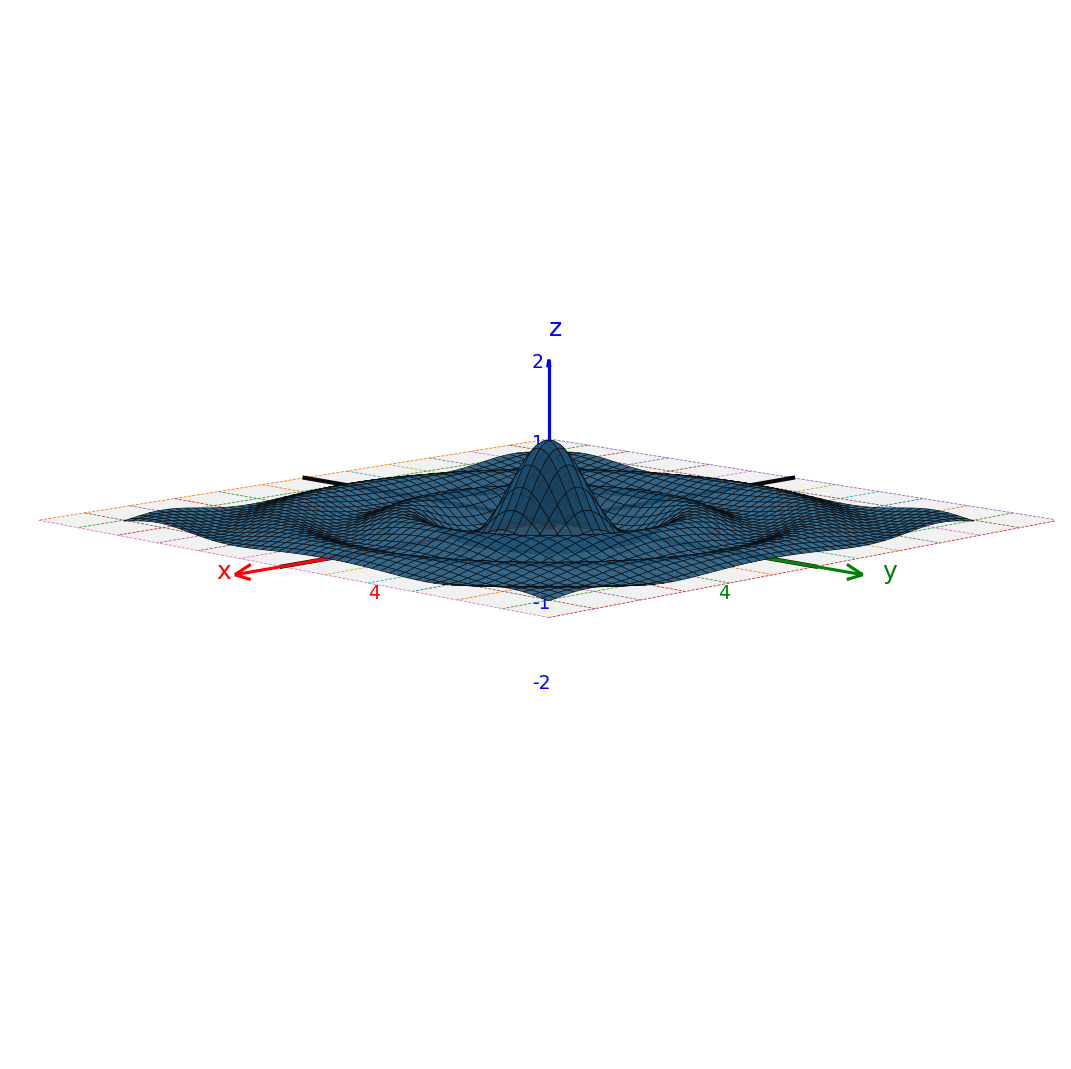

In [61]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =======================
#  Superficie de ejemplo
# =======================
x = np.linspace(-5, 5, 200)
y = np.linspace(-5, 5, 200)
X, Y = np.meshgrid(x, y)
R = np.sqrt(X**2 + Y**2)
Z = np.sinc(R)

# Figura un poco más grande y nítida  ###
fig = plt.figure(figsize=(9, 9), dpi=150)
ax = fig.add_subplot(111, projection='3d')

# ----- Superficie -----
ax.plot_surface(X, Y, Z,
                rstride=4, cstride=4,
                linewidth=0.3, edgecolor='k',
                alpha=0.9)

# =======================
#  Piso tipo "infinite grid"
# =======================
L = 6                   # alcance del piso
grid = np.linspace(-L, L, 13)

for yy in grid:
    ax.plot([-L, L], [yy, yy], [0, 0],
            linestyle='--', linewidth=0.4)
for xx in grid:
    ax.plot([xx, xx], [-L, L], [0, 0],
            linestyle='--', linewidth=0.4)

PX, PY = np.meshgrid(grid, grid)
PZ = np.zeros_like(PX)
ax.plot_surface(PX, PY, PZ, alpha=0.10, shade=False)

# ====== LÍNEAS X=0 E Y=0 EN EL PISO ======
ax.plot([-L, L], [0, 0], [0, 0], color='black', linewidth=2)
ax.plot([0, 0], [-L, L], [0, 0], color='black', linewidth=2)

# =======================
#  Ejes con flechas
# =======================
axis_len_xy = 7    ### x,y igual que antes
axis_len_z  = 2    ### z SOLO hasta el techo de zlim (-2,2)

ax.quiver(0, 0, 0, axis_len_xy, 0, 0,
          arrow_length_ratio=0.05, color='r')
ax.quiver(0, 0, 0, 0, axis_len_xy, 0,
          arrow_length_ratio=0.05, color='g')
ax.quiver(0, 0, 0, 0, 0, axis_len_z,
          arrow_length_ratio=0.05, color='b')

# etiquetas de ejes un poco MÁS ALLÁ de la punta
ax.text(axis_len_xy+0.4, 0, 0, 'x', fontsize=12, color='r')
ax.text(0, axis_len_xy+0.4, 0, 'y', fontsize=12, color='g')
ax.text(0, 0, axis_len_z+0.3, 'z', fontsize=12, color='b')   ###

# =======================
#  MARCAR EL ORIGEN
# =======================
ax.scatter([0], [0], [0], s=60, color='red', zorder=10)
d = 0.3
ax.plot([-d, d], [0, 0], [0, 0], color='red', linewidth=1.5)
ax.plot([0, 0], [-d, d], [0, 0], color='red', linewidth=1.5)
ax.plot([0, 0], [0, 0], [0, 0.6], color='red', linewidth=1)

# =======================
#  Estilo
# =======================
ax.set_xlim(-L, L)
ax.set_ylim(-L, L)
ax.set_zlim(-2, 2)
ax.set_box_aspect((1, 1, 0.45))

# Ocultamos ticks "reales"
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

ax.grid(False)
ax.xaxis.line.set_linewidth(0)
ax.yaxis.line.set_linewidth(0)
ax.zaxis.line.set_linewidth(0)

ax.xaxis.pane.set_alpha(0)
ax.yaxis.pane.set_alpha(0)
ax.zaxis.pane.set_alpha(0)

# ====== NÚMEROS MANUALES ======
ticks_xy = np.array([-4, 0, 4])      # referencias en x,y
ticks_z  = np.array([-2, -1, 0, 1, 2])

# x: sobre el piso, color del eje
for t in ticks_xy:
    ax.text(t, 0, -0.4, f"{t}",
            ha='center', va='top', fontsize=9, color='r')

# y: sobre el piso, color del eje
for t in ticks_xy:
    ax.text(0, t, -0.4, f"{t}",
            ha='center', va='top', fontsize=9, color='g')

# z: al lado del eje z, color azul
for t in ticks_z:
    ax.text(0.4, 0, t, f"{t}",
            ha='left', va='center', fontsize=9, color='b')

# Vista que te gusta
ax.view_init(elev=10, azim=45)

plt.show()


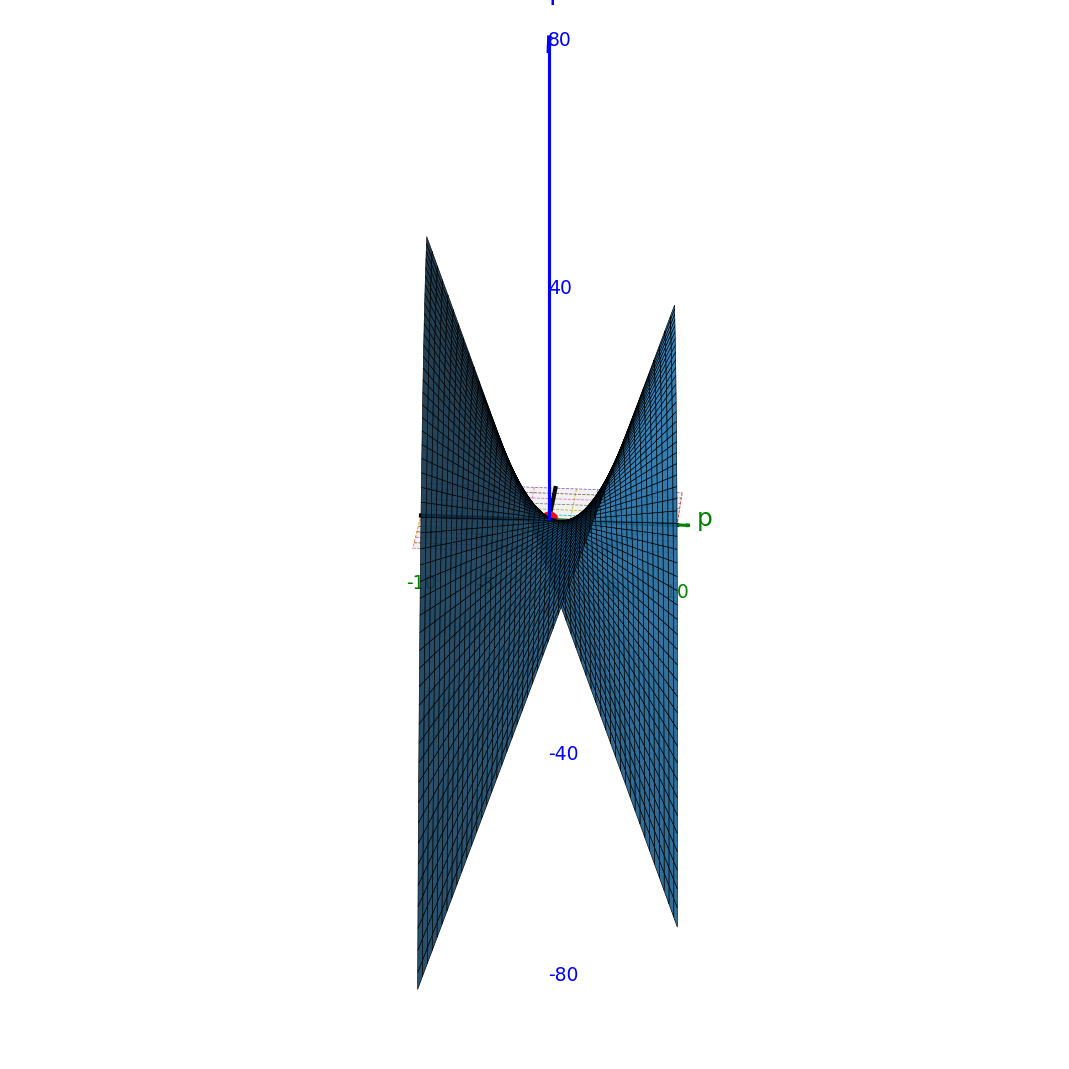

In [63]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =======================
#  Superficie F(x,p) = p x - x^2/2
# =======================
x = np.linspace(-6, 6, 200)
p = np.linspace(-10, 10, 200)
X, P = np.meshgrid(x, p)
F = P*X - X**2/2

fig = plt.figure(figsize=(9, 9), dpi=150)
ax = fig.add_subplot(111, projection='3d')

# ----- Superficie -----
ax.plot_surface(X, P, F,
                rstride=4, cstride=4,
                linewidth=0.3, edgecolor='k',
                alpha=0.9)

# =======================
#  Piso tipo "infinite grid" en el plano F=0
# =======================
Lx = 6
Lp = 10
grid_x = np.linspace(-Lx, Lx, 13)
grid_p = np.linspace(-Lp, Lp, 13)

for pp in grid_p:
    ax.plot([-Lx, Lx], [pp, pp], [0, 0],
            linestyle='--', linewidth=0.4)
for xx in grid_x:
    ax.plot([xx, xx], [-Lp, Lp], [0, 0],
            linestyle='--', linewidth=0.4)

PX, PY = np.meshgrid(grid_x, grid_p)
PZ = np.zeros_like(PX)
ax.plot_surface(PX, PY, PZ, alpha=0.10, shade=False)

# ====== LÍNEAS x=0 y p=0 EN EL PISO ======
ax.plot([-Lx, Lx], [0, 0], [0, 0], color='black', linewidth=2)
ax.plot([0, 0], [-Lp, Lp], [0, 0], color='black', linewidth=2)

# =======================
#  Ejes con flechas
# =======================
axis_len_x = 7
axis_len_p = 11
axis_len_F = 80   # acorde con zlim

ax.quiver(0, 0, 0, axis_len_x, 0, 0,
          arrow_length_ratio=0.03, color='r')   # eje x (rojo)
ax.quiver(0, 0, 0, 0, axis_len_p, 0,
          arrow_length_ratio=0.03, color='g')   # eje p (verde)
ax.quiver(0, 0, 0, 0, 0, axis_len_F,
          arrow_length_ratio=0.03, color='b')   # eje F (azul)

ax.text(axis_len_x+0.5, 0, 0, 'x', fontsize=12, color='r')
ax.text(0, axis_len_p+0.5, 0, 'p', fontsize=12, color='g')
ax.text(0, 0, axis_len_F+5, 'F', fontsize=12, color='b')

# =======================
#  MARCAR EL ORIGEN
# =======================
ax.scatter([0], [0], [0], s=60, color='red', zorder=10)
d = 0.3
ax.plot([-d, d], [0, 0], [0, 0], color='red', linewidth=1.5)
ax.plot([0, 0], [-d, d], [0, 0], color='red', linewidth=1.5)
ax.plot([0, 0], [0, 0], [0, 3], color='red', linewidth=1.5)

# =======================
#  Estilo
# =======================
ax.set_xlim(-Lx, Lx)
ax.set_ylim(-Lp, Lp)
ax.set_zlim(-80, 80)
ax.set_box_aspect((Lx, Lp, 40))  # proporción acorde a rangos

ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

ax.grid(False)
ax.xaxis.line.set_linewidth(0)
ax.yaxis.line.set_linewidth(0)
ax.zaxis.line.set_linewidth(0)

ax.xaxis.pane.set_alpha(0)
ax.yaxis.pane.set_alpha(0)
ax.zaxis.pane.set_alpha(0)

# ====== NÚMEROS MANUALES (opcionales) ======
ticks_x = np.array([-4, 0, 4])
ticks_p = np.array([-10, -5, 0, 5, 10])
ticks_F = np.array([-80, -40, 0, 40, 80])

for t in ticks_x:
    ax.text(t, 0, -10, f"{t}",
            ha='center', va='top', fontsize=9, color='r')
for t in ticks_p:
    ax.text(0, t, -10, f"{t}",
            ha='center', va='top', fontsize=9, color='g')
for t in ticks_F:
    ax.text(1, 0, t, f"{t}",
            ha='left', va='center', fontsize=9, color='b')

# Vista
ax.view_init(elev=25, azim=5)

plt.show()


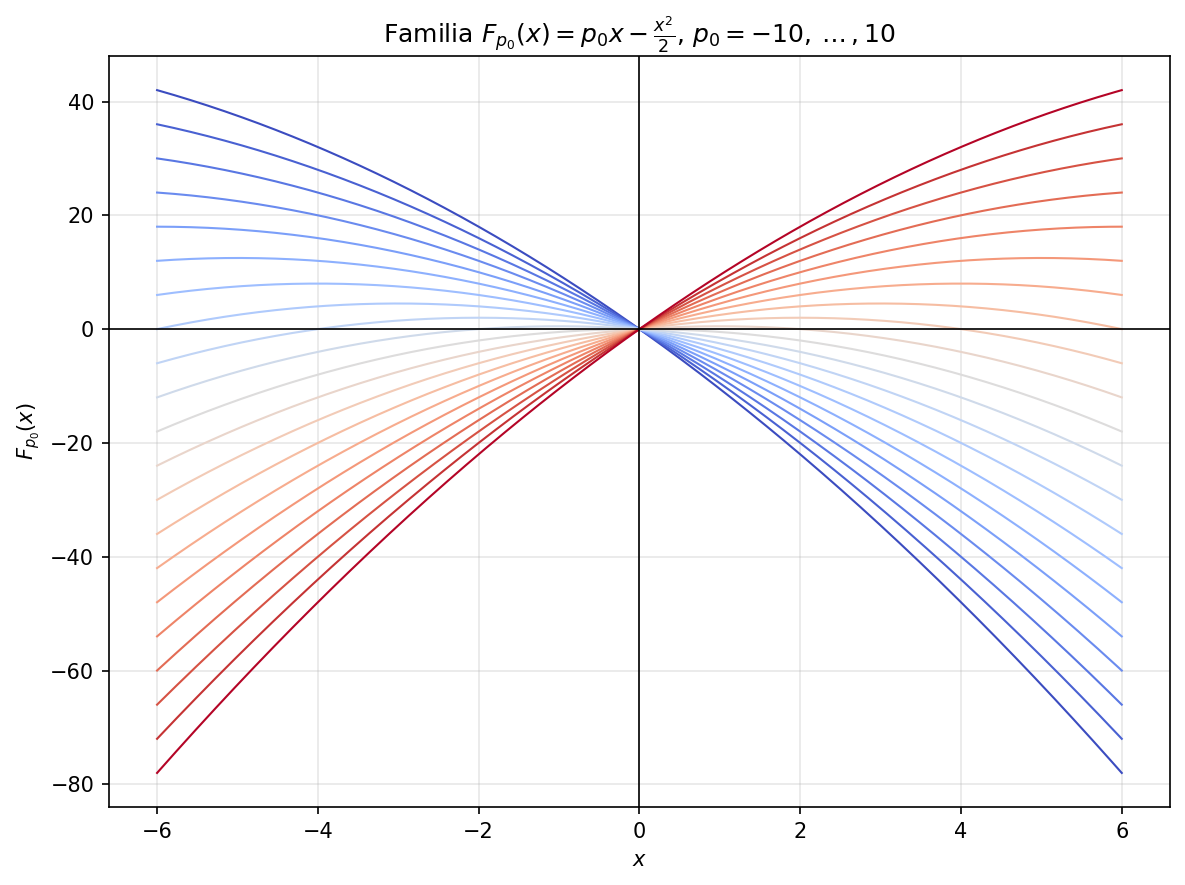

In [64]:
import numpy as np
import matplotlib.pyplot as plt

# Dominio en x
x = np.linspace(-6, 6, 400)

# Valores de p0
p0_values = np.arange(-10, 11, 1)   # -10, -9, ..., 10

plt.figure(figsize=(8, 6), dpi=150)

for p0 in p0_values:
    Fp = p0*x - x**2/2
    # colormap simple: color depende de p0
    color = plt.cm.coolwarm((p0 + 10)/20)  # normaliza a [0,1]
    plt.plot(x, Fp, color=color, linewidth=1)

plt.axhline(0, color='k', linewidth=0.8)
plt.axvline(0, color='k', linewidth=0.8)

plt.xlabel(r'$x$')
plt.ylabel(r'$F_{p_0}(x)$')
plt.title(r'Familia $F_{p_0}(x) = p_0 x - \frac{x^2}{2}$, $p_0=-10,\dots,10$')

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


<Axes3D: >

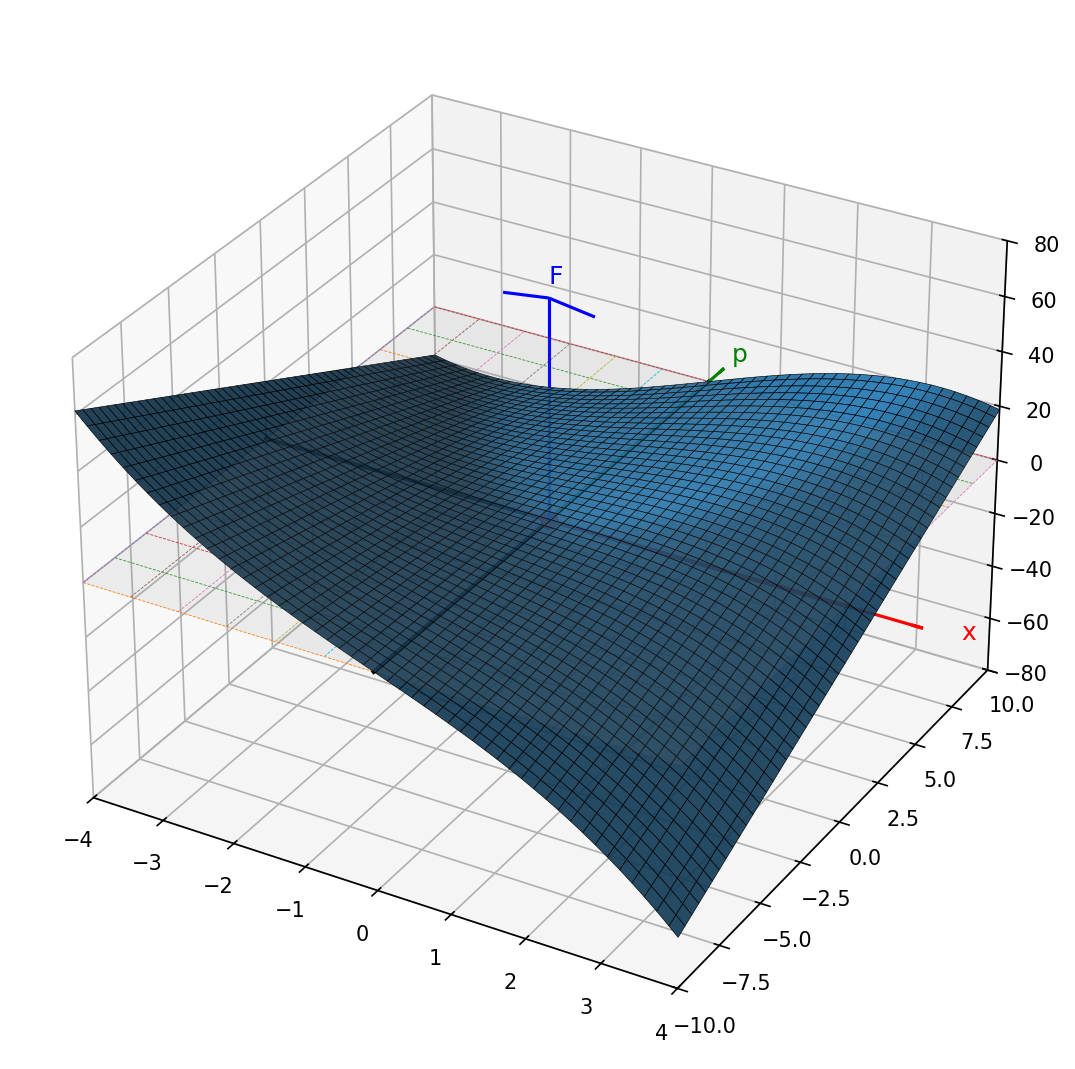

In [65]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =======================
#  Superficie F(x,p) = p x - x^3/3
# =======================
x = np.linspace(-4, 4, 200)
p = np.linspace(-10, 10, 200)
X, P = np.meshgrid(x, p)
F = P*X - X**3/3

fig = plt.figure(figsize=(9, 9), dpi=150)
ax = fig.add_subplot(111, projection='3d')

ax.plot_surface(X, P, F,
                rstride=4, cstride=4,
                linewidth=0.3, edgecolor='k',
                alpha=0.9)

# Piso F=0
Lx = 4
Lp = 10
grid_x = np.linspace(-Lx, Lx, 13)
grid_p = np.linspace(-Lp, Lp, 13)

for pp in grid_p:
    ax.plot([-Lx, Lx], [pp, pp], [0, 0],
            linestyle='--', linewidth=0.4)
for xx in grid_x:
    ax.plot([xx, xx], [-Lp, Lp], [0, 0],
            linestyle='--', linewidth=0.4)

PX, PY = np.meshgrid(grid_x, grid_p)
PZ = np.zeros_like(PX)
ax.plot_surface(PX, PY, PZ, alpha=0.10, shade=False)

# x=0, p=0
ax.plot([-Lx, Lx], [0, 0], [0, 0], color='black', linewidth=2)
ax.plot([0, 0], [-Lp, Lp], [0, 0], color='black', linewidth=2)

# Ejes
axis_len_x = 5
axis_len_p = 11
axis_len_F = 80

ax.quiver(0, 0, 0, axis_len_x, 0, 0,
          arrow_length_ratio=0.03, color='r')
ax.quiver(0, 0, 0, 0, axis_len_p, 0,
          arrow_length_ratio=0.03, color='g')
ax.quiver(0, 0, 0, 0, 0, axis_len_F,
          arrow_length_ratio=0.03, color='b')

ax.text(axis_len_x+0.5, 0, 0, 'x', fontsize=12, color='r')
ax.text(0, axis_len_p+0.5, 0, 'p', fontsize=12, color='g')
ax.text(0, 0, axis_len_F+5, 'F', fontsize=12, color='b')

# Origen
ax.scatter([0], [0], [0], s=60, color='red', zorder=10)
d = 0.3
ax.plot([-d, d], [0, 0], [0, 0], color='red', linewidth=1.5)
ax.plot([0, 0], [-d, d], [0, 0], color='red', linewidth=1.5)
ax.plot([0, 0], [0, 0], [0, 3], color='red', linewidth=1.5)

# Estilo
ax.set_xlim(-Lx, Lx)
ax.set_ylim(-Lp, Lp)
ax.set_zlim(-80, 80)
ax


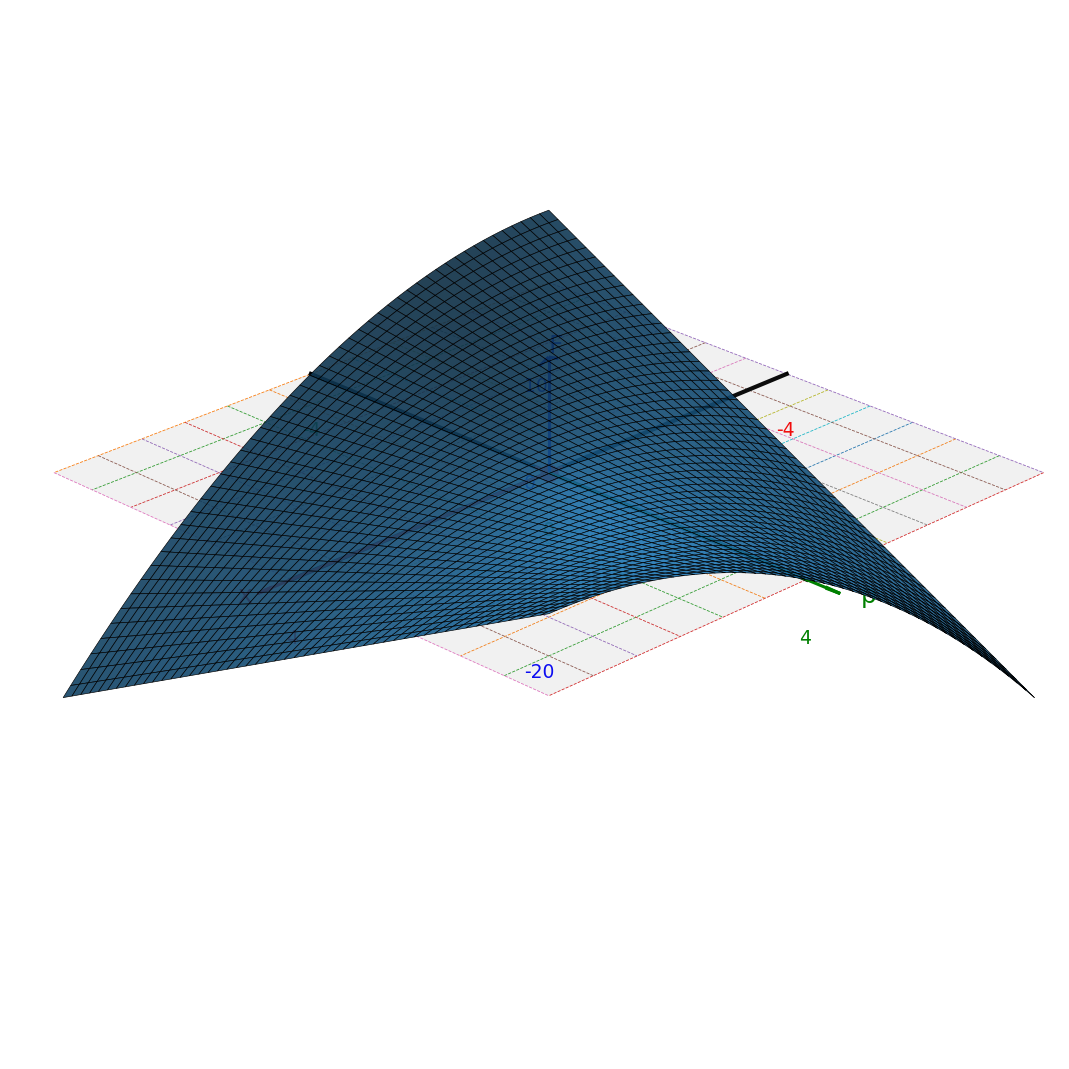

In [66]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# =======================
#  Superficie F(x,p) = p x - x^2/2
# =======================
x = np.linspace(-4, 4, 200)
p = np.linspace(-4, 4, 200)
X, P = np.meshgrid(x, p)
F = P*X - X**2/2

# Figura un poco más grande y nítida
fig = plt.figure(figsize=(9, 9), dpi=150)
ax = fig.add_subplot(111, projection='3d')

# ----- Superficie -----
ax.plot_surface(X, P, F,
                rstride=4, cstride=4,
                linewidth=0.3, edgecolor='k',
                alpha=0.9)

# =======================
#  Piso tipo "infinite grid" en F = 0
# =======================
Lx = 4
Lp = 4
grid_x = np.linspace(-Lx, Lx, 13)
grid_p = np.linspace(-Lp, Lp, 13)

for pp in grid_p:
    ax.plot([-Lx, Lx], [pp, pp], [0, 0],
            linestyle='--', linewidth=0.4)
for xx in grid_x:
    ax.plot([xx, xx], [-Lp, Lp], [0, 0],
            linestyle='--', linewidth=0.4)

PX, PY = np.meshgrid(grid_x, grid_p)
PZ = np.zeros_like(PX)
ax.plot_surface(PX, PY, PZ, alpha=0.10, shade=False)

# ====== LÍNEAS x=0 y p=0 EN EL PISO ======
ax.plot([-Lx, Lx], [0, 0], [0, 0], color='black', linewidth=2)
ax.plot([0, 0], [-Lp, Lp], [0, 0], color='black', linewidth=2)

# =======================
#  Ejes con flechas
# =======================
axis_len_x = 4.5
axis_len_p = 4.5
axis_len_F = 12    # acorde con zlim

ax.quiver(0, 0, 0, axis_len_x, 0, 0,
          arrow_length_ratio=0.05, color='r')   # eje x
ax.quiver(0, 0, 0, 0, axis_len_p, 0,
          arrow_length_ratio=0.05, color='g')   # eje p
ax.quiver(0, 0, 0, 0, 0, axis_len_F,
          arrow_length_ratio=0.05, color='b')   # eje F

ax.text(axis_len_x+0.3, 0, 0, 'x', fontsize=12, color='r')
ax.text(0, axis_len_p+0.3, 0, 'p', fontsize=12, color='g')
ax.text(0, 0, axis_len_F+0.5, 'F', fontsize=12, color='b')

# =======================
#  MARCAR EL ORIGEN
# =======================
ax.scatter([0], [0], [0], s=60, color='red', zorder=10)
d = 0.2
ax.plot([-d, d], [0, 0], [0, 0], color='red', linewidth=1.5)
ax.plot([0, 0], [-d, d], [0, 0], color='red', linewidth=1.5)
ax.plot([0, 0], [0, 0], [0, 0.6], color='red', linewidth=1.5)

# =======================
#  Estilo
# =======================
ax.set_xlim(-Lx, Lx)
ax.set_ylim(-Lp, Lp)
ax.set_zlim(-25, 15)  # cubre aprox. el rango de F en [-4,4]x[-4,4]
ax.set_box_aspect((1, 1, 0.6))

# Quitamos ticks reales
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

ax.grid(False)
ax.xaxis.line.set_linewidth(0)
ax.yaxis.line.set_linewidth(0)
ax.zaxis.line.set_linewidth(0)
ax.xaxis.pane.set_alpha(0)
ax.yaxis.pane.set_alpha(0)
ax.zaxis.pane.set_alpha(0)

# ====== NÚMEROS MANUALES ======
ticks_x = np.array([-4, 0, 4])
ticks_p = np.array([-4, 0, 4])
ticks_F = np.array([-20, 0, 10])

for t in ticks_x:
    ax.text(t, 0, -5, f"{t}",
            ha='center', va='top', fontsize=9, color='r')
for t in ticks_p:
    ax.text(0, t, -5, f"{t}",
            ha='center', va='top', fontsize=9, color='g')
for t in ticks_F:
    ax.text(0.4, 0, t, f"{t}",
            ha='left', va='center', fontsize=9, color='b')

# Vista "clásica" 3D
ax.view_init(elev=25, azim=45)

plt.show()


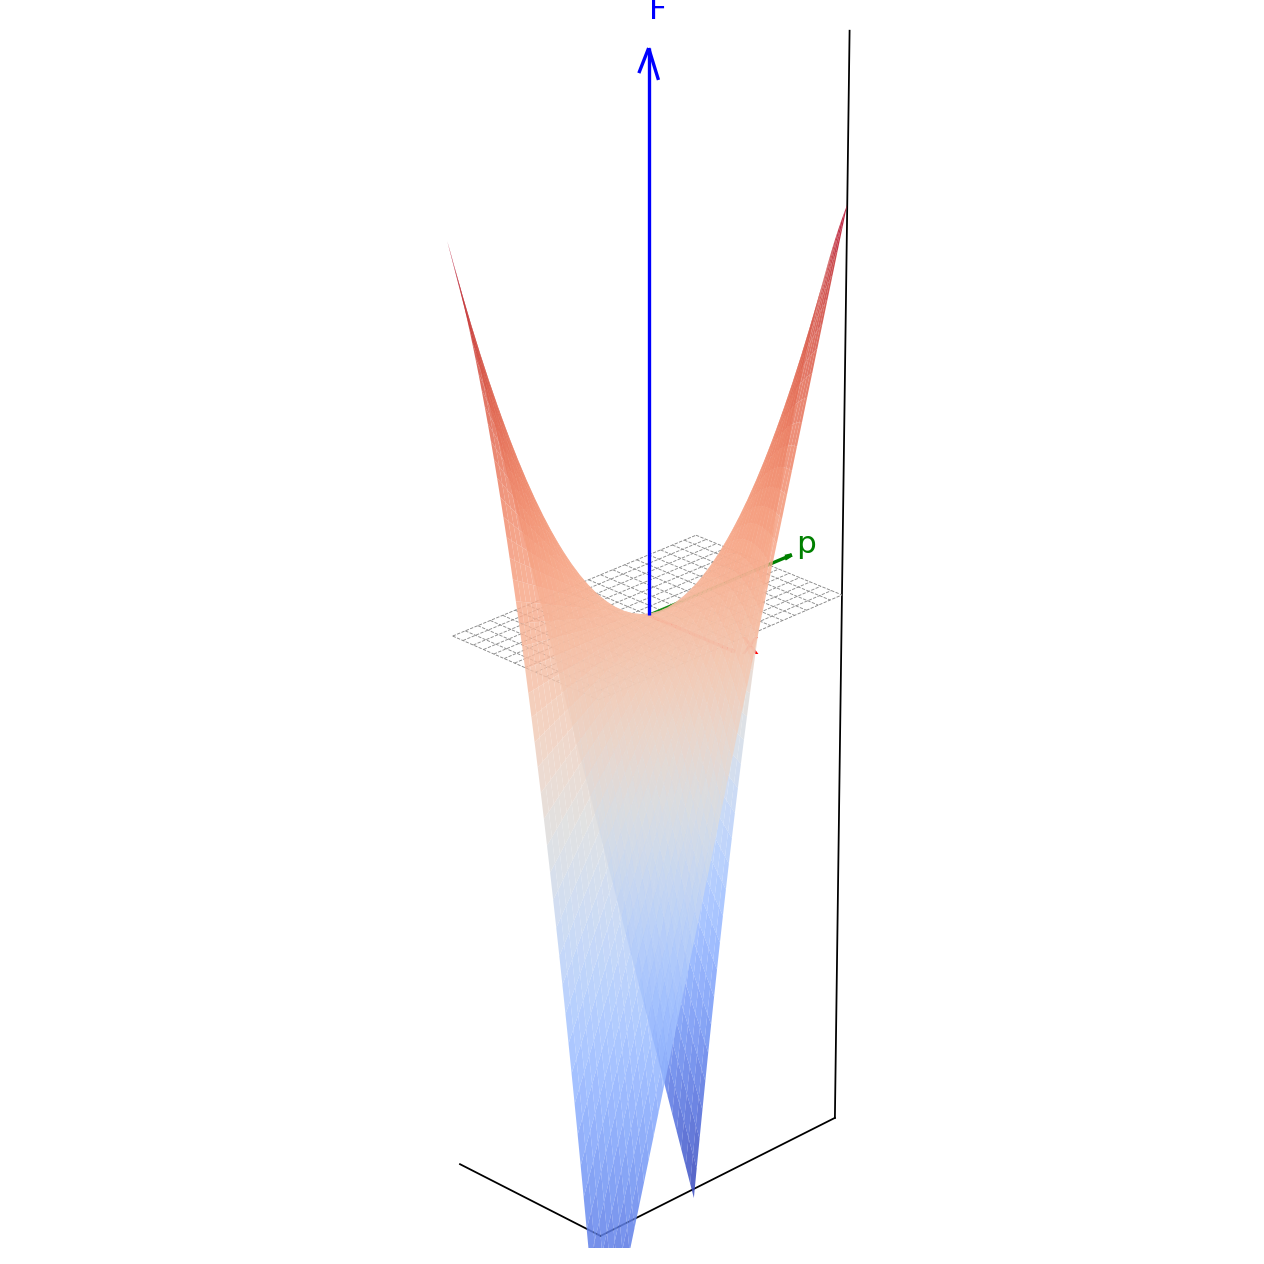

In [67]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from matplotlib import cm

# =====================================
#       Superficie F(x,p) = px - x²/2
# =====================================
x = np.linspace(-6, 6, 300)
p = np.linspace(-10, 10, 300)
X, P = np.meshgrid(x, p)
F = P*X - 0.5*X**2

fig = plt.figure(figsize=(10, 10), dpi=160)
ax = fig.add_subplot(111, projection='3d')

# -------- SUPERFICIE con buen SHADING --------
surf = ax.plot_surface(
    X, P, F,
    linewidth=0,
    antialiased=True,
    cmap=cm.coolwarm,
    alpha=0.85,
    shade=True
)

# -------- GRADIENTE VISUAL SUAVE --------
surf.set_facecolor((0.2, 0.4, 0.7, 0.7))

# =====================================
#          Piso tipo GeoGebra
# =====================================
Lx = 6
Lp = 10
grid_x = np.linspace(-Lx, Lx, 15)
grid_p = np.linspace(-Lp, Lp, 21)

PX, PY = np.meshgrid(grid_x, grid_p)
PZ = np.zeros_like(PX)
ax.plot_surface(PX, PY, PZ,
                alpha=0.10, color='white', shade=False)

# Líneas sobre el piso
for pp in grid_p:
    ax.plot([-Lx, Lx], [pp, pp], [0, 0], color='gray', linestyle='--', linewidth=0.4)
for xx in grid_x:
    ax.plot([xx, xx], [-Lp, Lp], [0, 0], color='gray', linestyle='--', linewidth=0.4)

# Ejes bonitos
ax.quiver(0, 0, 0, 7, 0, 0, color='r', arrow_length_ratio=0.05)
ax.quiver(0, 0, 0, 0, 12, 0, color='g', arrow_length_ratio=0.05)
ax.quiver(0, 0, 0, 0, 0, 60, color='b', arrow_length_ratio=0.05)

ax.text(7.4, 0, 0, "x", fontsize=14, color='r')
ax.text(0, 12.4, 0, "p", fontsize=14, color='g')
ax.text(0, 0, 63, "F", fontsize=14, color='b')

# Mejores límites
ax.set_xlim(-6, 6)
ax.set_ylim(-10, 10)
ax.set_zlim(-60, 60)
ax.set_box_aspect((6, 10, 35))

# Ocultar ticks reales
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

# Transparencias del plano
ax.xaxis.pane.set_alpha(0)
ax.yaxis.pane.set_alpha(0)
ax.zaxis.pane.set_alpha(0)

# Vista tipo GeoGebra
ax.view_init(elev=25, azim=-45)

plt.show()


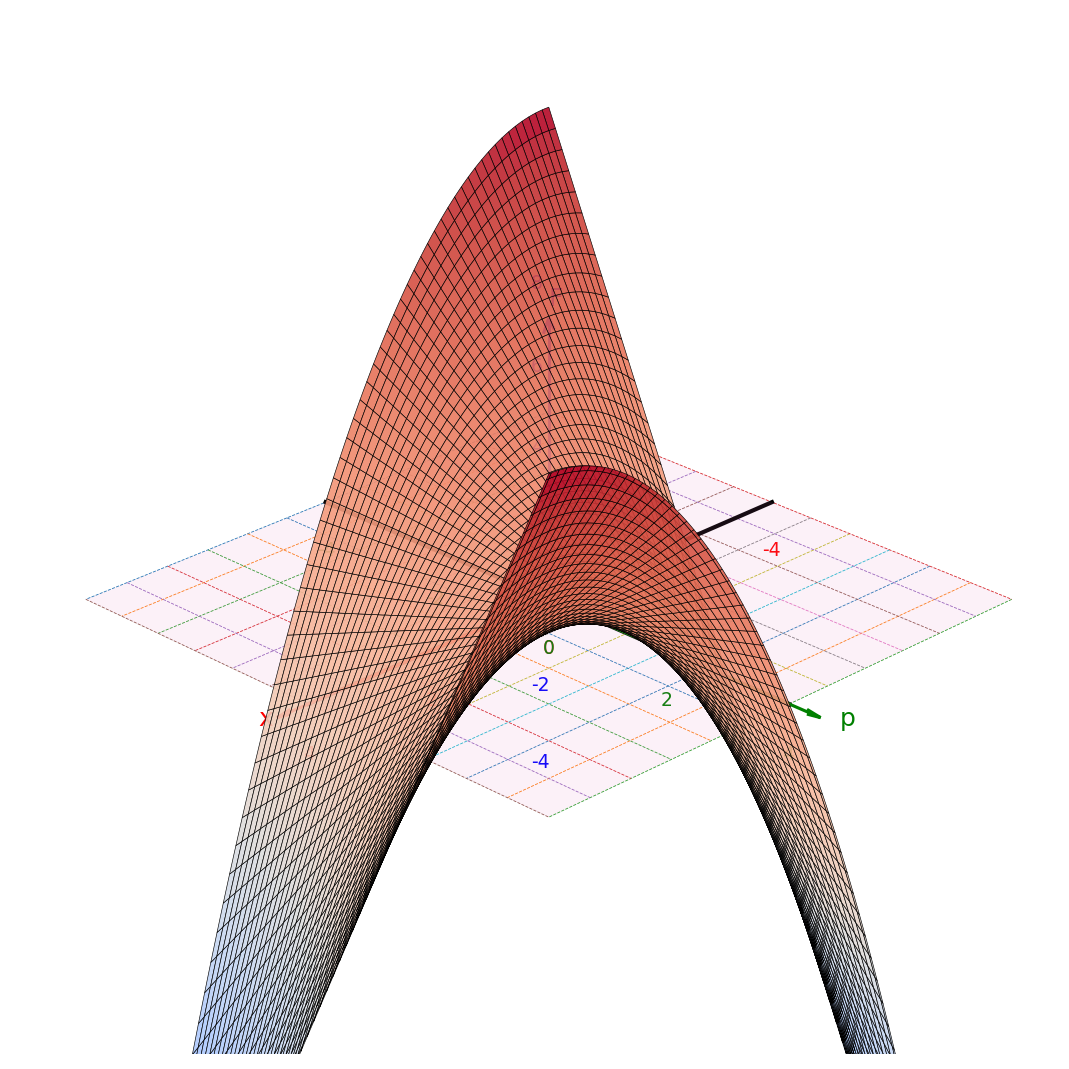

In [68]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D   # sólo para activar '3d'

# =======================
#  Superficie F(x,p) = p x - x^2/2
# =======================
x = np.linspace(-4, 4, 200)
p = np.linspace(-4, 4, 200)
X, P = np.meshgrid(x, p)
F = P*X - X**2/2

# Figura grande y nítida
fig = plt.figure(figsize=(9, 9), dpi=150)
ax = fig.add_subplot(111, projection='3d')

# ----- Superficie -----
surf = ax.plot_surface(
    X, P, F,
    rstride=3, cstride=3,
    linewidth=0.3,
    edgecolor='k',
    alpha=0.9,
    cmap='coolwarm'
)

# =======================
#  "Piso" tipo infinite grid en F = 0
# =======================
L = 4                    # alcance del piso en x y p
grid = np.linspace(-L, L, 13)

for pp in grid:
    ax.plot([-L, L], [pp, pp], [0, 0],
            linestyle='--', linewidth=0.4)
for xx in grid:
    ax.plot([xx, xx], [-L, L], [0, 0],
            linestyle='--', linewidth=0.4)

PX, PY = np.meshgrid(grid, grid)
PZ = np.zeros_like(PX)
ax.plot_surface(PX, PY, PZ, alpha=0.10, shade=False)

# ====== LÍNEAS x=0 y p=0 EN EL PISO ======
ax.plot([-L, L], [0, 0], [0, 0], color='black', linewidth=2)
ax.plot([0, 0], [-L, L], [0, 0], color='black', linewidth=2)

# =======================
#  Ejes con flechas (x, p, F)
# =======================
axis_len_xy = 4.5     # un poco más allá del piso
axis_len_F  = 7       # techo del eje F

ax.quiver(0, 0, 0, axis_len_xy, 0, 0,
          arrow_length_ratio=0.05, color='r')   # x
ax.quiver(0, 0, 0, 0, axis_len_xy, 0,
          arrow_length_ratio=0.05, color='g')   # p
ax.quiver(0, 0, 0, 0, 0, axis_len_F,
          arrow_length_ratio=0.05, color='b')   # F

ax.text(axis_len_xy+0.3, 0, 0, 'x', fontsize=12, color='r')
ax.text(0, axis_len_xy+0.3, 0, 'p', fontsize=12, color='g')
ax.text(0, 0, axis_len_F+0.3, 'F', fontsize=12, color='b')

# =======================
#  ORIGEN MARCADO
# =======================
ax.scatter([0], [0], [0], s=60, color='red', zorder=10)
d = 0.25
ax.plot([-d, d], [0, 0], [0, 0], color='red', linewidth=1.5)
ax.plot([0, 0], [-d, d], [0, 0], color='red', linewidth=1.5)
ax.plot([0, 0], [0, 0], [0, 0.6], color='red', linewidth=1)

# =======================
#  Estilo y rangos
# =======================
ax.set_xlim(-L, L)
ax.set_ylim(-L, L)
ax.set_zlim(-4, 8)         # mucho más comprimido que [-80, 80]
ax.set_box_aspect((1, 1, 0.8))

# Quitamos ticks "reales"
ax.set_xticks([])
ax.set_yticks([])
ax.set_zticks([])

ax.grid(False)
ax.xaxis.line.set_linewidth(0)
ax.yaxis.line.set_linewidth(0)
ax.zaxis.line.set_linewidth(0)

ax.xaxis.pane.set_alpha(0)
ax.yaxis.pane.set_alpha(0)
ax.zaxis.pane.set_alpha(0)

# ====== NÚMEROS MANUALES (referencias) ======
ticks_xy = np.array([-4, -2, 0, 2, 4])
ticks_F  = np.array([-4, -2, 0, 2, 4, 6, 8])

for t in ticks_xy:
    ax.text(t, 0, -1.0, f"{t}",
            ha='center', va='top', fontsize=9, color='r')
for t in ticks_xy:
    ax.text(0, t, -1.0, f"{t}",
            ha='center', va='top', fontsize=9, color='g')
for t in ticks_F:
    ax.text(0.3, 0, t, f"{t}",
            ha='left', va='center', fontsize=9, color='b')

# Vista tipo GeoGebra (ajusta a tu gusto)
ax.view_init(elev=25, azim=45)

plt.show()
